# AirCommand - IPN Hand Dataset EDA

Exploratory analysis of the IPN Hand gesture recognition dataset.

This notebook analyzes annotation-level information before
MediaPipe landmark extraction.

In [226]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0,str(PROJECT_ROOT))
from src.data.dataset import get_dataset_paths
from src.data.annotations import (
    load_train_annotations,
    load_test_annotations,
    load_class_mapping
)
from src.data.validation import validate_dataset

In [227]:
paths = get_dataset_paths()
train_df = load_train_annotations(paths)
test_df = load_test_annotations(paths)
classes_df = load_class_mapping(paths)

validate_dataset(paths,train_df,test_df,classes_df)
print("Dataset loaded and validated successfully.")

Dataset loaded and validated successfully.


## 1. Dataset Overview

We first inspect the shape, columns, and basic structure of the
training and test annotation tables.

In [228]:
print("Training annotations:", train_df.shape)
print("Test annotations:", test_df.shape)
print("Class mapping:", classes_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nClass mapping:")
display(classes_df)

Training annotations: (4039, 6)
Test annotations: (1610, 6)
Class mapping: (14, 3)

Training columns:
['video', 'label', 'class_id', 'start_frame', 'end_frame', 'frame_count']

Test columns:
['video', 'label', 'class_id', 'start_frame', 'end_frame', 'frame_count']

Class mapping:


,class_id,label,gesture
0,1,D0X,Non-gesture
1,2,B0A,Pointing with one finger
2,3,B0B,Pointing with two fingers
3,4,G01,Click with one finger
4,5,G02,Click with two fingers
5,6,G03,Throw up
6,7,G04,Throw down
7,8,G05,Throw left
8,9,G06,Throw right
9,10,G07,Open twice


## 2. Class Distribution

We examine how many annotated segments belong to each gesture class.
This helps us identify class imbalance before model training.

In [229]:
train_counts = train_df["label"].value_counts()
test_counts = test_df["label"].value_counts()

class_order = classes_df["label"]

train_counts = train_counts.reindex(class_order, fill_value=0)
test_counts = test_counts.reindex(class_order, fill_value=0)

distribution_df = pd.DataFrame({
    "gesture": class_order,
    "train": train_counts.values,
    "test": test_counts.values,
})

distribution_df

,gesture,train,test
0,D0X,922,509
1,B0A,745,265
2,B0B,743,264
3,G01,148,52
4,G02,148,52
5,G03,148,52
6,G04,149,52
7,G05,148,52
8,G06,148,52
9,G07,148,52


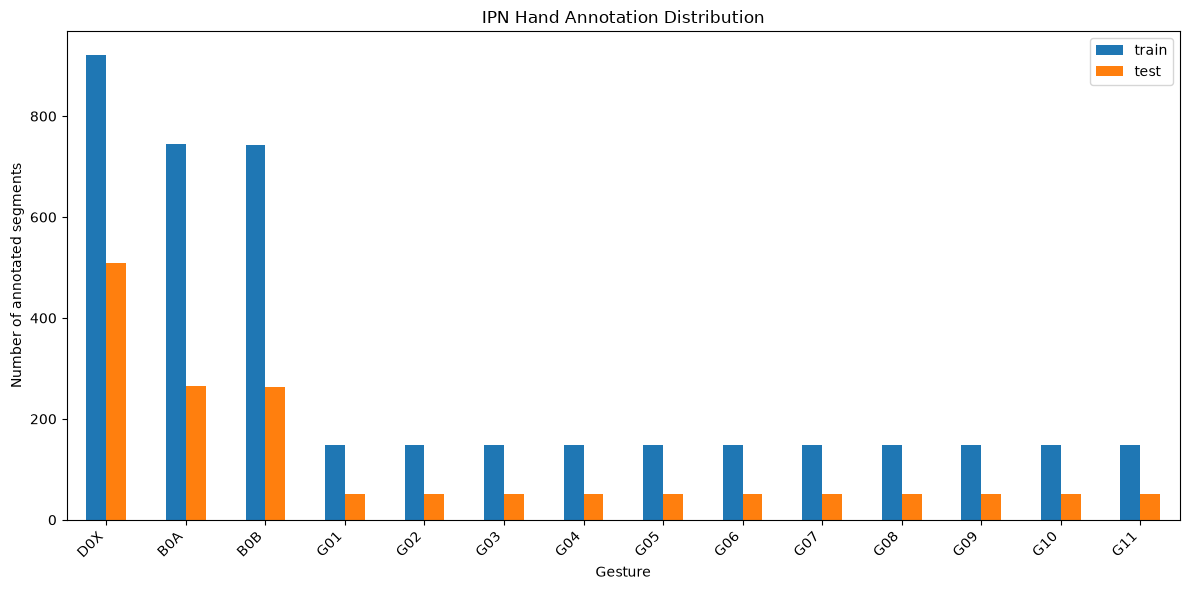

In [230]:
ax = distribution_df.set_index("gesture")[["train", "test"]].plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_title("IPN Hand Annotation Distribution")
ax.set_xlabel("Gesture")
ax.set_ylabel("Number of annotated segments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 3. Segment Length Distribution

Each annotation represents a temporal segment containing a variable
number of frames. We examine the distribution of segment lengths
before designing the sequence preprocessing strategy.

In [231]:
train_df["frame_count"].describe()

count    4039.000000
mean      145.657093
std       105.971996
min         9.000000
25%        56.000000
50%       114.000000
75%       218.000000
max       970.000000
Name: frame_count, dtype: float64

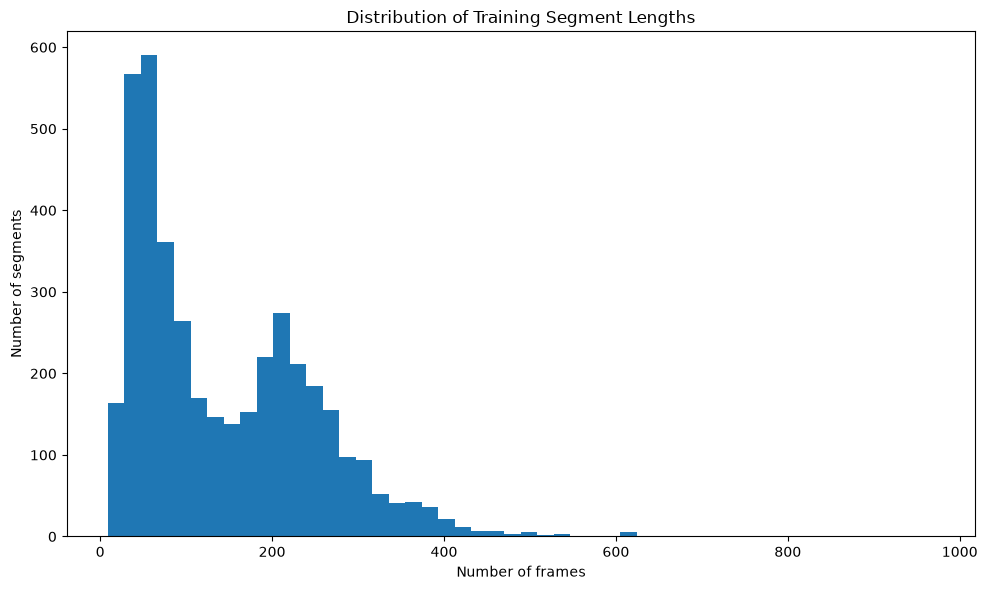

In [232]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["frame_count"],
    bins=50,
)

plt.title("Distribution of Training Segment Lengths")
plt.xlabel("Number of frames")
plt.ylabel("Number of segments")

plt.tight_layout()
plt.show()

In [233]:
segments_per_video = (
    train_df
    .groupby("video")
    .size()
)

segments_per_video.describe()

count    148.000000
mean      27.290541
std        4.641213
min       25.000000
25%       26.000000
50%       26.000000
75%       26.000000
max       43.000000
dtype: float64

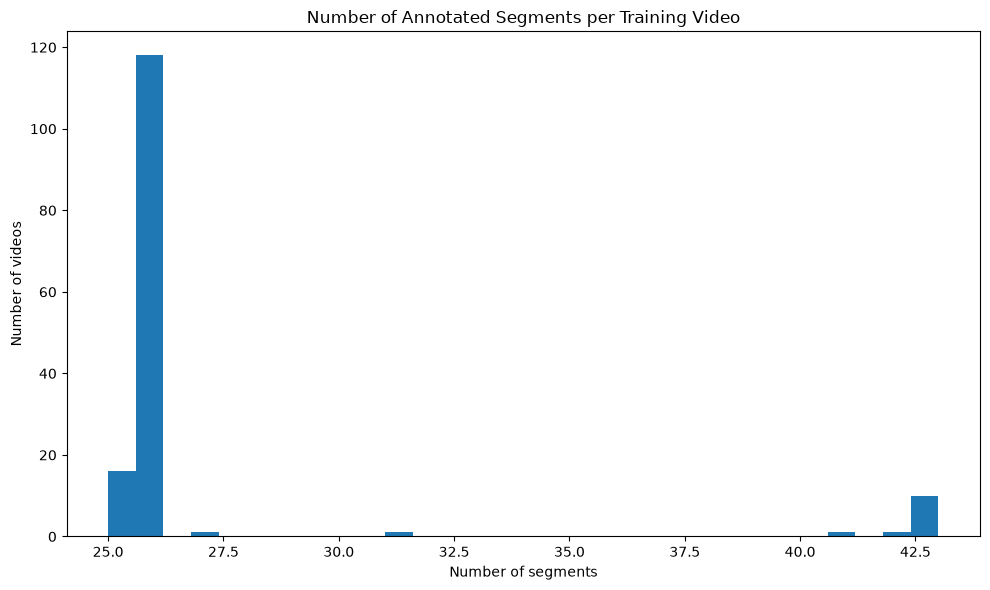

In [234]:
plt.figure(figsize=(10, 6))

plt.hist(
    segments_per_video,
    bins=30,
)

plt.title("Number of Annotated Segments per Training Video")
plt.xlabel("Number of segments")
plt.ylabel("Number of videos")

plt.tight_layout()
plt.show()

## 4. Segment Length by Gesture Class

We examine segment-length statistics for each gesture class to
understand whether long segments are associated with particular
classes.

In [235]:
segment_stats_by_class = (
    train_df
    .groupby("label")["frame_count"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reindex(classes_df["label"])
)

segment_stats_by_class

,count,mean,median,min,max
label,,,,,
D0X,922,166.880694,121.0,9,970
B0A,745,217.570470,214.0,9,624
B0B,743,222.098250,216.0,15,623
G01,148,55.993243,47.0,13,167
G02,148,61.040541,48.5,18,525
G03,148,61.601351,55.5,15,139
G04,149,65.644295,60.0,13,181
G05,148,66.743243,59.0,22,165
G06,148,64.851351,57.0,26,174


<Figure size 1200x600 with 0 Axes>

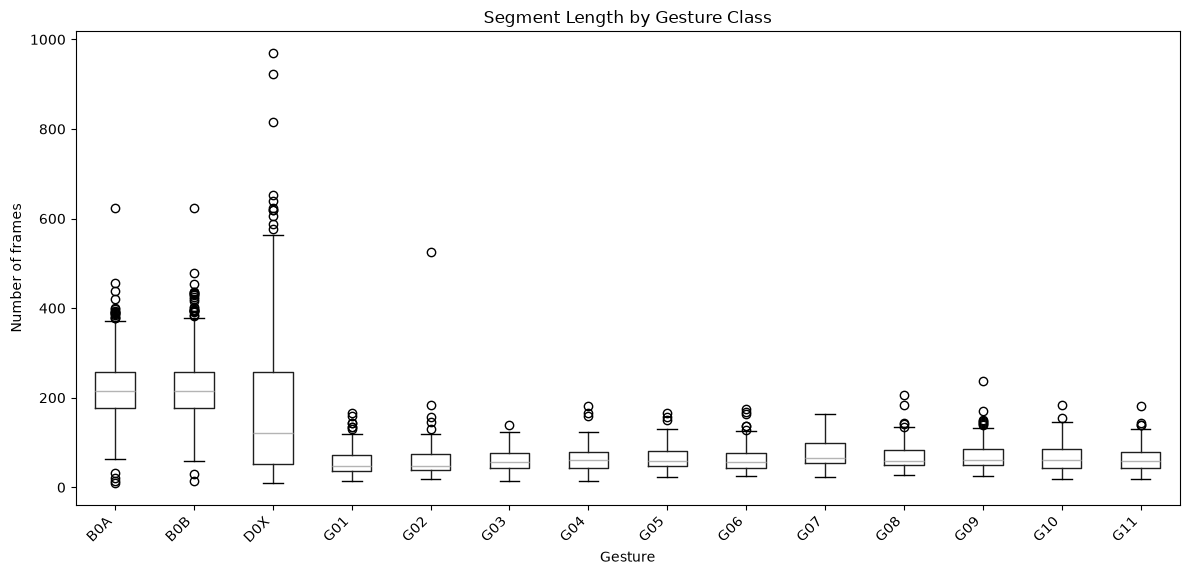

In [236]:
plt.figure(figsize=(12, 6))

train_df.boxplot(
    column="frame_count",
    by="label",
    figsize=(12, 6),
    grid=False,
)

plt.title("Segment Length by Gesture Class")
plt.suptitle("")
plt.xlabel("Gesture")
plt.ylabel("Number of frames")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [237]:
longest_segments = (
    train_df
    .sort_values("frame_count", ascending=False)
    .head(20)
)

longest_segments[
    [
        "video",
        "label",
        "start_frame",
        "end_frame",
        "frame_count",
    ]
]

,video,label,start_frame,end_frame,frame_count
1225,1CM42_6_R__164,D0X,1783,2752,970
1168,1CM42_6_R__162,D0X,641,1562,922
1200,1CM42_6_R__163,D0X,1360,2174,815
1146,1CM42_6_R__161,D0X,1089,1740,652
1222,1CM42_6_R__164,D0X,925,1564,640
1152,1CM42_6_R__161,D0X,2853,3476,624
2147,1CV12_6_R__80,B0A,98,721,624
1616,1CV12_16_R__107,B0B,2003,2625,623
1149,1CM42_6_R__161,D0X,1996,2615,620
2964,4CM11_16_R__210,D0X,619,1238,620


In [238]:
train_df["duration_seconds"] = train_df["frame_count"] / 30
train_df["duration_seconds"].describe()

count    4039.000000
mean        4.855236
std         3.532400
min         0.300000
25%         1.866667
50%         3.800000
75%         7.266667
max        32.333333
Name: duration_seconds, dtype: float64

In [239]:
duration_stats_by_class = (
    train_df
    .groupby("label")["duration_seconds"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reindex(classes_df["label"])
)

duration_stats_by_class

,count,mean,median,min,max
label,,,,,
D0X,922,5.562690,4.033333,0.300000,32.333333
B0A,745,7.252349,7.133333,0.300000,20.800000
B0B,743,7.403275,7.200000,0.500000,20.766667
G01,148,1.866441,1.566667,0.433333,5.566667
G02,148,2.034685,1.616667,0.600000,17.500000
G03,148,2.053378,1.850000,0.500000,4.633333
G04,149,2.188143,2.000000,0.433333,6.033333
G05,148,2.224775,1.966667,0.733333,5.500000
G06,148,2.161712,1.900000,0.866667,5.800000


In [240]:
duration_thresholds = [1, 2, 3, 5, 10, 20]
duration_by_class = {}

for threshold in duration_thresholds:
    duration_by_class[f">{threshold}s"] = (
        train_df
        .groupby("label")["duration_seconds"]
        .apply(lambda values: (values > threshold).mean() * 100)
    )

duration_by_class = pd.DataFrame(duration_by_class).reindex(
    classes_df["label"]
)

duration_by_class

,>1s,>2s,>3s,>5s,>10s,>20s
label,,,,,,
D0X,87.744035,69.414317,57.375271,45.878525,16.811280,0.976139
B0A,99.597315,99.463087,97.449664,84.697987,10.738255,0.134228
B0B,99.730821,99.461642,97.308210,86.810229,11.574697,0.134590
G01,82.432432,31.756757,12.837838,1.351351,0.000000,0.000000
G02,88.513514,37.837838,12.837838,2.027027,0.675676,0.000000
G03,97.297297,41.891892,16.216216,0.000000,0.000000,0.000000
G04,96.644295,48.993289,18.120805,2.013423,0.000000,0.000000
G05,95.270270,48.648649,18.243243,2.027027,0.000000,0.000000
G06,95.945946,45.270270,19.594595,2.027027,0.000000,0.000000


In [241]:
train_video_count = train_df["video"].nunique()
test_video_count = test_df["video"].nunique()

print("Training videos:", train_video_count)
print("Test videos:", test_video_count)
print("Total videos:", train_video_count + test_video_count)

Training videos: 148
Test videos: 52
Total videos: 200


In [242]:
video_class_counts = (
    train_df.groupby(["video","label"]).size().unstack(fill_value=0)
)
video_class_counts.head()

label,B0A,B0B,D0X,G01,G02,G03,G04,G05,G06,G07,G08,G09,G10,G11
video,,,,,,,,,,,,,,
1CM1_4_R__229,5,5,5,1,1,1,1,1,1,1,1,1,1,1
1CM1_4_R__230,5,5,5,1,1,1,1,1,1,1,1,1,1,1
1CM1_4_R__231,5,5,5,1,1,1,1,1,1,1,1,1,1,1
1CM1_4_R__232,5,5,5,1,1,1,1,1,1,1,1,1,1,1
1CM42_11_R__205,5,5,4,1,1,1,1,1,1,1,1,1,1,1


## 5. Video Metadata Analysis

The IPN Hand dataset provides metadata describing recording conditions,
including hand used, background, illumination, people in the scene,
background motion, and official train/test assignment.

We examine these attributes to understand the diversity of the
recordings used by the model.

In [243]:
metadata_df = pd.read_excel(paths.metadata)

print("Metadata shape:", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

display(metadata_df.head())

Metadata shape: (200, 9)

Metadata columns:
['Video Name', 'Frames', 'Sex', 'Hand', 'Background', 'Illumination', 'People in Scene', 'Background Motion', 'Set']


,Video Name,Frames,Sex,Hand,Background,Illumination,People in Scene,Background Motion,Set
0,1CM1_4_R__229,3751,W,Right,Clutter,Stable,Single,Static,train
1,1CM1_4_R__230,3684,W,Right,Clutter,Stable,Single,Static,train
2,1CM1_4_R__231,3747,W,Right,Clutter,Stable,Single,Static,train
3,1CM1_4_R__232,3858,W,Right,Clutter,Stable,Single,Static,train
4,1CM42_11_R__205,3686,M,Right,Plain,Stable,Single,Static,train


In [244]:
categorical_columns = [
    "Sex",
    "Hand",
    "Background",
    "Illumination",
    "People in Scene",
    "Background Motion",
    "Set",
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(metadata_df[column].value_counts())


--- Sex ---
Sex
M    136
W     64
Name: count, dtype: int64

--- Hand ---
Hand
Right    187
Left      13
Name: count, dtype: int64

--- Background ---
Background
Clutter     103
Plain        94
Clutter       3
Name: count, dtype: int64

--- Illumination ---
Illumination
Stable    131
Light      57
Dark       12
Name: count, dtype: int64

--- People in Scene ---
People in Scene
Single    171
Multi      29
Name: count, dtype: int64

--- Background Motion ---
Background Motion
Static     153
Dynamic     47
Name: count, dtype: int64

--- Set ---
Set
train    148
test      52
Name: count, dtype: int64


In [245]:
metadata_df["Frames"].describe()

count     200.000000
mean     4002.525000
std       341.564608
min      3601.000000
25%      3727.750000
50%      3910.500000
75%      4200.750000
max      5038.000000
Name: Frames, dtype: float64

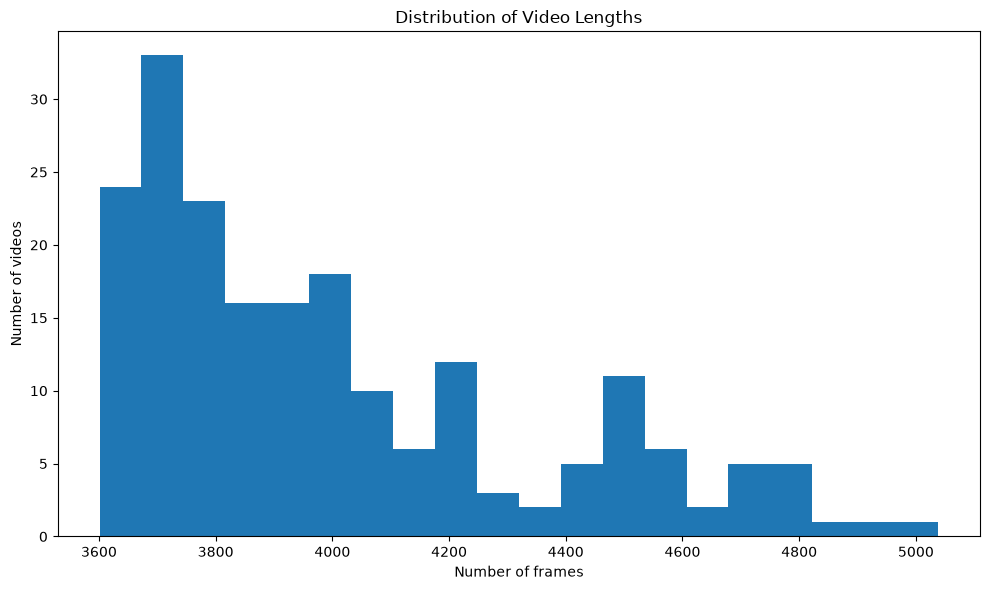

In [246]:
plt.figure(figsize=(10, 6))

plt.hist(
    metadata_df["Frames"],
    bins=20,
)

plt.title("Distribution of Video Lengths")
plt.xlabel("Number of frames")
plt.ylabel("Number of videos")

plt.tight_layout()
plt.show()

In [247]:
metadata_df["Background_clean"] = (
    metadata_df["Background"]
    .astype(str)
    .str.strip()
)
print(metadata_df["Background_clean"].value_counts())

Background_clean
Clutter    106
Plain       94
Name: count, dtype: int64


In [248]:
import importlib
from src.data.video_validation import validate_all_videos

all_annotations = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

video_validation_df = validate_all_videos(
    paths,
    metadata_df,
    all_annotations
)

Validating videos:   0%|          | 1/200 [00:01<04:08,  1.25s/it]

Validating video: 1CM1_4_R__229.avi | actual_frames=3807 | max_annotated_frame=3751


Validating videos:   1%|          | 2/200 [00:02<03:39,  1.11s/it]

Validating video: 1CM1_4_R__230.avi | actual_frames=3739 | max_annotated_frame=3684


Validating videos:   2%|▏         | 3/200 [00:03<03:12,  1.03it/s]

...

Validating video: 4CM11_18_R__48.avi | actual_frames=3697 | max_annotated_frame=3697
Validating video: 4CM11_20_R__41.avi | actual_frames=3746 | max_annotated_frame=3746
Validating video: 4CM11_20_R__42.avi | actual_frames=3743 | max_annotated_frame=3743
Validating video: 4CM11_20_R__43.avi | actual_frames=4005 | max_annotated_frame=4005


Validating videos:  98%|█████████▊| 197/200 [00:26<00:00,  9.40it/s]

Validating video: 4CM11_20_R__44.avi | actual_frames=4120 | max_annotated_frame=4120
Validating video: 4CM11_24_L__61.avi | actual_frames=4026 | max_annotated_frame=4026
Validating video: 4CM11_24_L__62.avi | actual_frames=3751 | max_annotated_frame=3751


Validating videos: 100%|██████████| 200/200 [00:27<00:00,  7.39it/s]

Validating video: 4CM11_24_L__63.avi | actual_frames=4000 | max_annotated_frame=4000
Validating video: 4CM11_24_L__64.avi | actual_frames=3920 | max_annotated_frame=3920


In [249]:
from src.data.video_validation import validate_all_videos

all_annotations = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

video_validation_df = validate_all_videos(
    paths,
    metadata_df,
    all_annotations
)

display(
    video_validation_df[
        [
            "video",
            "metadata_frames",
            "actual_frames",
            "max_annotated_frame",
            "frame_count_matches",
            "annotation_within_video",
            "frames_decoded",
        ]
    ]
)

Validating videos:   0%|          | 1/200 [00:00<00:59,  3.33it/s]

Validating video: 1CM1_4_R__229.avi | actual_frames=3807 | max_annotated_frame=3751


Validating videos:   1%|          | 2/200 [00:00<00:55,  3.55it/s]

Validating video: 1CM1_4_R__230.avi | actual_frames=3739 | max_annotated_frame=3684


Validating videos:   2%|▏         | 3/200 [00:00<00:50,  3.86it/s]

...

Validating videos:  96%|█████████▋| 193/200 [00:12<00:00, 21.18it/s]

Validating video: 4CM11_18_R__48.avi | actual_frames=3697 | max_annotated_frame=3697
Validating video: 4CM11_20_R__41.avi | actual_frames=3746 | max_annotated_frame=3746
Validating video: 4CM11_20_R__42.avi | actual_frames=3743 | max_annotated_frame=3743
Validating video: 4CM11_20_R__43.avi | actual_frames=4005 | max_annotated_frame=4005
Validating video: 4CM11_20_R__44.avi | actual_frames=4120 | max_annotated_frame=4120
Validating video: 4CM11_24_L__61.avi | actual_frames=4026 | max_annotated_frame=4026


Validating videos: 100%|██████████| 200/200 [00:12<00:00, 15.58it/s]

Validating video: 4CM11_24_L__62.avi | actual_frames=3751 | max_annotated_frame=3751
Validating video: 4CM11_24_L__63.avi | actual_frames=4000 | max_annotated_frame=4000
Validating video: 4CM11_24_L__64.avi | actual_frames=3920 | max_annotated_frame=3920


,video,metadata_frames,actual_frames,max_annotated_frame,frame_count_matches,annotation_within_video,frames_decoded
0,1CM1_4_R__229,3751,3807,3751,False,True,True
1,1CM1_4_R__230,3684,3739,3684,False,True,True
2,1CM1_4_R__231,3747,3802,3747,False,True,True
3,1CM1_4_R__232,3858,3913,3858,False,True,True
4,1CM42_11_R__205,3686,3686,3686,True,True,True
...,...,...,...,...,...,...,...
195,4CM11_20_R__44,4120,4120,4120,True,True,True
196,4CM11_24_L__61,4026,4026,4026,True,True,True
197,4CM11_24_L__62,3751,3751,3751,True,True,True
198,4CM11_24_L__63,4000,4000,4000,True,True,True


In [250]:
video_validation_df["frames_decoded"].value_counts()

frames_decoded
True    200
Name: count, dtype: int64

In [251]:
video_validation_df["annotation_within_video"].value_counts()

annotation_within_video
True    200
Name: count, dtype: int64

In [252]:
video_validation_df["frame_count_matches"].value_counts()

frame_count_matches
True     177
False     23
Name: count, dtype: int64

In [253]:
video_validation_df[
    ~video_validation_df["frames_decoded"]
][
    [
        "video",
        "metadata_frames",
        "actual_frames",
        "max_annotated_frame",
        "frame_count_matches",
        "annotation_within_video",
        "frames_decoded",
    ]
]

,video,metadata_frames,actual_frames,max_annotated_frame,frame_count_matches,annotation_within_video,frames_decoded


In [254]:
video_validation_df[
    ~video_validation_df["frames_decoded"]
][
    ["video", "actual_frames", "max_annotated_frame"]
]

,video,actual_frames,max_annotated_frame


In [255]:
video_validation_df["frames_decoded"].value_counts()

frames_decoded
True    200
Name: count, dtype: int64

In [256]:
import cv2
video_name = "1CM1_4_R__229"

video_path = video_validation_df.loc[
    video_validation_df["video"] == video_name,
    "path"
].iloc[0]

max_frame = int(
    video_validation_df.loc[
        video_validation_df["video"] == video_name,
        "max_annotated_frame"
    ].iloc[0]
)

capture = cv2.VideoCapture(str(video_path))

for position in range(max_frame - 5, max_frame + 3):
    capture.set(cv2.CAP_PROP_POS_FRAMES, position)

    success, frame = capture.read()

    print(
        f"Frame {position}: "
        f"success={success}, "
        f"frame_exists={frame is not None}"
    )

capture.release()

Frame 3746: success=True, frame_exists=True
Frame 3747: success=True, frame_exists=True
Frame 3748: success=True, frame_exists=True
Frame 3749: success=True, frame_exists=True
Frame 3750: success=True, frame_exists=True
Frame 3751: success=True, frame_exists=True
Frame 3752: success=True, frame_exists=True
Frame 3753: success=True, frame_exists=True


In [257]:
video_validation_df["frames_decoded"].value_counts()

frames_decoded
True    200
Name: count, dtype: int64

In [258]:
import importlib

import src.data.video_validation as video_validation

importlib.reload(video_validation)

from src.data.video_validation import validate_all_videos

In [259]:
all_annotations = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

video_validation_df = validate_all_videos(
    paths,
    metadata_df,
    all_annotations
)

Validating videos:   0%|          | 1/200 [00:00<01:20,  2.48it/s]

Validating video: 1CM1_4_R__229.avi | actual_frames=3807 | max_annotated_frame=3751


Validating videos:   1%|          | 2/200 [00:00<01:16,  2.59it/s]

Validating video: 1CM1_4_R__230.avi | actual_frames=3739 | max_annotated_frame=3684


Validating videos:   2%|▏         | 3/200 [00:01<01:08,  2.86it/s]

...

Validating video: 4CM11_13_R__30.avi | actual_frames=3953 | max_annotated_frame=3953
Validating video: 4CM11_13_R__31.avi | actual_frames=3945 | max_annotated_frame=3945
Validating video: 4CM11_13_R__32.avi | actual_frames=3881 | max_annotated_frame=3881
Validating video: 4CM11_18_R__45.avi | actual_frames=3664 | max_annotated_frame=3664
Validating video: 4CM11_18_R__46.avi | actual_frames=3739 | max_annotated_frame=3739


Validating videos:  96%|█████████▋| 193/200 [00:10<00:00, 22.61it/s]

Validating video: 4CM11_18_R__47.avi | actual_frames=3691 | max_annotated_frame=3691
Validating video: 4CM11_18_R__48.avi | actual_frames=3697 | max_annotated_frame=3697
Validating video: 4CM11_20_R__41.avi | actual_frames=3746 | max_annotated_frame=3746
Validating video: 4CM11_20_R__42.avi | actual_frames=3743 | max_annotated_frame=3743
Validating video: 4CM11_20_R__43.avi | actual_frames=4005 | max_annotated_frame=4005
Validating video: 4CM11_20_R__44.avi | actual_frames=4120 | max_annotated_frame=4120


Validating videos: 100%|██████████| 200/200 [00:11<00:00, 17.74it/s]

Validating video: 4CM11_24_L__61.avi | actual_frames=4026 | max_annotated_frame=4026
Validating video: 4CM11_24_L__62.avi | actual_frames=3751 | max_annotated_frame=3751
Validating video: 4CM11_24_L__63.avi | actual_frames=4000 | max_annotated_frame=4000
Validating video: 4CM11_24_L__64.avi | actual_frames=3920 | max_annotated_frame=3920


In [260]:
video_validation_df["frames_decoded"].value_counts()

frames_decoded
True    200
Name: count, dtype: int64

In [261]:
video_validation_df[
    ~video_validation_df["frames_decoded"]
][
    [
        "video",
        "metadata_frames",
        "actual_frames",
        "max_annotated_frame",
        "frame_count_matches",
        "annotation_within_video",
        "frames_decoded",
    ]
]

,video,metadata_frames,actual_frames,max_annotated_frame,frame_count_matches,annotation_within_video,frames_decoded


In [262]:
import importlib

import src.data.video_validation as video_validation

importlib.reload(video_validation)

from src.data.video_validation import validate_all_videos

In [263]:
all_annotations = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

video_validation_df = validate_all_videos(
    paths,
    metadata_df,
    all_annotations
)

Validating videos:   0%|          | 1/200 [00:00<01:22,  2.40it/s]

Validating video: 1CM1_4_R__229.avi | actual_frames=3807 | max_annotated_frame=3751


Validating videos:   1%|          | 2/200 [00:00<01:26,  2.30it/s]

Validating video: 1CM1_4_R__230.avi | actual_frames=3739 | max_annotated_frame=3684


Validating videos:   2%|▏         | 3/200 [00:01<01:20,  2.44it/s]

...

Validating video: 4CM11_13_R__29.avi | actual_frames=3841 | max_annotated_frame=3841
Validating video: 4CM11_13_R__30.avi | actual_frames=3953 | max_annotated_frame=3953
Validating video: 4CM11_13_R__31.avi | actual_frames=3945 | max_annotated_frame=3945
Validating video: 4CM11_13_R__32.avi | actual_frames=3881 | max_annotated_frame=3881
Validating video: 4CM11_18_R__45.avi | actual_frames=3664 | max_annotated_frame=3664


Validating videos:  96%|█████████▌| 192/200 [00:11<00:00, 22.78it/s]

Validating video: 4CM11_18_R__46.avi | actual_frames=3739 | max_annotated_frame=3739
Validating video: 4CM11_18_R__47.avi | actual_frames=3691 | max_annotated_frame=3691
Validating video: 4CM11_18_R__48.avi | actual_frames=3697 | max_annotated_frame=3697
Validating video: 4CM11_20_R__41.avi | actual_frames=3746 | max_annotated_frame=3746
Validating video: 4CM11_20_R__42.avi | actual_frames=3743 | max_annotated_frame=3743
Validating video: 4CM11_20_R__43.avi | actual_frames=4005 | max_annotated_frame=4005
Validating video: 4CM11_20_R__44.avi | actual_frames=4120 | max_annotated_frame=4120


Validating videos: 100%|██████████| 200/200 [00:11<00:00, 16.69it/s]

Validating video: 4CM11_24_L__61.avi | actual_frames=4026 | max_annotated_frame=4026
Validating video: 4CM11_24_L__62.avi | actual_frames=3751 | max_annotated_frame=3751
Validating video: 4CM11_24_L__63.avi | actual_frames=4000 | max_annotated_frame=4000
Validating video: 4CM11_24_L__64.avi | actual_frames=3920 | max_annotated_frame=3920


In [264]:
video_validation_df["frames_decoded"].value_counts()

frames_decoded
True    200
Name: count, dtype: int64

In [265]:
from src.config.settings import DATASET_ROOT
from src.data.dataset import get_dataset_paths
from src.features.landmarks import create_hand_detector, extract_segment_landmarks


paths = get_dataset_paths()

video_path = paths.videos / "1CM1_4_R__229.avi"

detector = create_hand_detector()

landmarks, detections = extract_segment_landmarks(
    video_path=video_path,
    start_frame=18,
    end_frame=55,
    detector=detector,
)

print("Landmarks shape:", landmarks.shape)
print("Detection shape:", detections.shape)
print("Frames with hand detected:", detections.sum())
print("Total frames:", len(detections))

Landmarks shape: (38, 21, 3)
Detection shape: (38,)
Frames with hand detected: 38
Total frames: 38


In [266]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("MediaPipe location:", mp.__file__)
print("Has solutions:", hasattr(mp, "solutions"))


MediaPipe version: 1.0.1
MediaPipe location: c:\Users\smrut\Documents\Projects\AirCommand\.myenv\Lib\site-packages\mediapipe\__init__.py
Has solutions: False


In [267]:
import importlib
import src.config.settings as settings

settings = importlib.reload(settings)

print("Model path:")
print(settings.MEDIAPIPE_HAND_LANDMARKER_MODEL)

print("\nExists:")
print(settings.MEDIAPIPE_HAND_LANDMARKER_MODEL.exists())

Model path:
C:\Users\smrut\Documents\Projects\AirCommand\models\mediapipe\hand_landmarker.task

Exists:
True


In [268]:
print(hasattr(settings, "MEDIAPIPE_HAND_LANDMARKER_MODEL"))

True


In [269]:
import src.features.landmarks as landmarks

landmarks = importlib.reload(landmarks)

detector = landmarks.create_hand_detector()

print("Hand detector created successfully.")

Hand detector created successfully.


In [270]:
import cv2

video_path = paths.videos / "1CM1_4_R__229.avi"

capture = cv2.VideoCapture(str(video_path))

if not capture.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

capture.set(cv2.CAP_PROP_POS_FRAMES, 18)

success, frame = capture.read()

capture.release()

print("Frame read successfully:", success)
print("Frame shape:", frame.shape if frame is not None else None)

Frame read successfully: True
Frame shape: (480, 640, 3)


In [271]:
result = landmarks.extract_landmarks(
    frame=frame,
    detector=detector,
    timestamp_ms=18,
)

print("Hand detected:", result.hand_detected)
print("Landmarks shape:", result.landmarks.shape)
print("First 5 landmarks:")
print(result.landmarks[:5])

Hand detected: True
Landmarks shape: (21, 3)
First 5 landmarks:
[[ 3.7592882e-01  7.3428923e-01  3.2315609e-07]
 [ 4.2246819e-01  6.8073672e-01 -1.8622255e-02]
 [ 4.4510260e-01  6.1046052e-01 -3.1432550e-02]
 [ 4.5222765e-01  5.6456244e-01 -4.6580009e-02]
 [ 4.4036934e-01  5.4335773e-01 -6.0467061e-02]]


In [272]:
import importlib
import src.features.landmarks as landmarks

landmarks = importlib.reload(landmarks)

In [273]:
detector = landmarks.create_hand_detector()

In [274]:
video_path = paths.videos / "1CM1_4_R__229.avi"

landmark_sequence, detection_sequence = (
    landmarks.extract_segment_landmarks(
        video_path=video_path,
        start_frame=18,
        end_frame=55,
        detector=detector,
    )
)

In [275]:
print("Landmark sequence shape:", landmark_sequence.shape)
print("Detection sequence shape:", detection_sequence.shape)
print("Frames with hand detected:", detection_sequence.sum())
print("Total frames:", len(detection_sequence))

Landmark sequence shape: (38, 21, 3)
Detection sequence shape: (38,)
Frames with hand detected: 38
Total frames: 38


In [276]:
detector.close()

In [277]:
raw_landmarks = result.landmarks

normalized_landmarks = landmarks.normalize_landmarks(
    raw_landmarks
)

print("Raw shape:", raw_landmarks.shape)
print("Normalized shape:", normalized_landmarks.shape)
print("Normalized wrist:", normalized_landmarks[0])
print("First 5 normalized landmarks:")
print(normalized_landmarks[:5])

Raw shape: (21, 3)
Normalized shape: (21, 3)
Normalized wrist: [0. 0. 0.]
First 5 normalized landmarks:
[[ 0.          0.          0.        ]
 [ 0.04653937 -0.05355251 -0.01862258]
 [ 0.06917378 -0.12382871 -0.03143287]
 [ 0.07629883 -0.16972679 -0.04658033]
 [ 0.06444052 -0.1909315  -0.06046738]]


In [279]:
import numpy as np
print("Maximum absolute coordinate:")
print(np.max(np.abs(normalized_landmarks)))

print("\nMinimum coordinate:")
print(np.min(normalized_landmarks))

print("\nMaximum coordinate:")
print(np.max(normalized_landmarks))

Maximum absolute coordinate:
0.3428537

Minimum coordinate:
-0.3428537

Maximum coordinate:
0.083960414


In [280]:
wrist = normalized_landmarks[0]
middle_mcp = normalized_landmarks[9]

hand_scale = np.linalg.norm(
    middle_mcp - wrist
)

print("Hand scale:", hand_scale)

Hand scale: 0.23820624


In [281]:
scales = []

for frame_landmarks in landmark_sequence:
    normalized_frame = landmarks.normalize_landmarks(
        frame_landmarks
    )

    wrist = normalized_frame[0]
    middle_mcp = normalized_frame[9]

    scale = np.linalg.norm(
        middle_mcp - wrist
    )

    scales.append(scale)

scales = np.array(scales)

print("Minimum scale:", scales.min())
print("Maximum scale:", scales.max())
print("Mean scale:", scales.mean())
print("Standard deviation:", scales.std())

Minimum scale: 0.2171738
Maximum scale: 0.25489503
Mean scale: 0.2322277
Standard deviation: 0.008842514


In [282]:
normalized_sequence = landmarks.normalize_landmarks(
    landmark_sequence
)

print("Original shape:", landmark_sequence.shape)
print("Normalized shape:", normalized_sequence.shape)
print("First frame wrist:", normalized_sequence[0, 0])
print("Last frame wrist:", normalized_sequence[-1, 0])

Original shape: (38, 21, 3)
Normalized shape: (38, 21, 3)
First frame wrist: [0. 0. 0.]
Last frame wrist: [ 1.3185233e-01 -3.6918342e-02  5.8905124e-07]


In [283]:
print("Original first-frame wrist:")
print(landmark_sequence[0, 0])

print("\nOriginal last-frame wrist:")
print(landmark_sequence[-1, 0])

print("\nNormalized first-frame wrist:")
print(normalized_sequence[0, 0])

print("\nNormalized last-frame wrist:")
print(normalized_sequence[-1, 0])

Original first-frame wrist:
[3.7592882e-01 7.3428923e-01 3.2315609e-07]

Original last-frame wrist:
[5.0778115e-01 6.9737089e-01 9.1220733e-07]

Normalized first-frame wrist:
[0. 0. 0.]

Normalized last-frame wrist:
[ 1.3185233e-01 -3.6918342e-02  5.8905124e-07]


In [284]:
import inspect

print(inspect.getsource(landmarks.normalize_landmarks))

def normalize_landmarks(landmarks: np.ndarray)-> np.ndarray:
    """Normalize hand landmarks relative to the wrist."""
    wrist = landmarks[:,0:1,:]
    normalized = landmarks - wrist
    return normalized



In [285]:
import importlib
import src.features.landmarks as landmarks

landmarks = importlib.reload(landmarks)

In [286]:
import inspect

print(inspect.getsource(landmarks.normalize_landmarks))

def normalize_landmarks(landmarks: np.ndarray)-> np.ndarray:
    """Normalize hand landmarks relative to the wrist."""
    wrist = landmarks[:,0:1,:]
    normalized = landmarks - wrist
    return normalized



In [304]:
import importlib
import src.features.landmarks as landmarks

landmarks = importlib.reload(landmarks)

In [292]:
normalized_sequence = landmarks.normalize_landmarks(
    landmark_sequence
)

print("Original shape:", landmark_sequence.shape)
print("Normalized shape:", normalized_sequence.shape)

print("First frame wrist:", normalized_sequence[0, 0])
print("Last frame wrist:", normalized_sequence[-1, 0])

Original shape: (38, 21, 3)
Normalized shape: (38, 21, 3)
First frame wrist: [0. 0. 0.]
Last frame wrist: [0. 0. 0.]


In [293]:
from src.features.landmarks import flatten_landmarks
flattened_sequence = flatten_landmarks(
    normalized_sequence
)

print("Input shape:", normalized_sequence.shape)
print("Flattened shape:", flattened_sequence.shape)
print("First frame shape:", flattened_sequence[0].shape)
print("First frame features:")
print(flattened_sequence[0])

Input shape: (38, 21, 3)
Flattened shape: (38, 63)
First frame shape: (63,)
First frame features:
[ 0.          0.          0.          0.04653937 -0.05355251 -0.01862258
  0.06917378 -0.12382871 -0.03143287  0.07629883 -0.16972679 -0.04658033
  0.06444052 -0.1909315  -0.06046738  0.03825551 -0.24343953 -0.01223616
  0.04450691 -0.31094882 -0.04161984  0.0650439  -0.31320104 -0.06601521
  0.08396041 -0.29144585 -0.08097935 -0.0004659  -0.23730442 -0.02070284
 -0.00491592 -0.32067996 -0.04693425  0.02067348 -0.34206676 -0.06721287
  0.04515696 -0.3428537  -0.08104295 -0.03620741 -0.20921522 -0.0340198
 -0.04270053 -0.28159207 -0.06399001 -0.0149413  -0.2920084  -0.08247242
  0.01121837 -0.28653073 -0.09267764 -0.06550965 -0.16373348 -0.04941289
 -0.05084872 -0.19556004 -0.07521745 -0.02552825 -0.2141046  -0.09036717
 -0.00127345 -0.22777092 -0.10016001]


In [297]:
gesture_sequence = landmarks.create_gesture_sequence(
    video="1CM1_4_R__229",
    label="G11",
    class_id=14,
    landmarks=flattened_sequence,
    hand_detected=detection_sequence,
)

print("Video:", gesture_sequence.video)
print("Label:", gesture_sequence.label)
print("Class ID:", gesture_sequence.class_id)
print("Landmarks shape:", gesture_sequence.landmarks.shape)
print("Detection shape:", gesture_sequence.hand_detected.shape)

Video: 1CM1_4_R__229
Label: G11
Class ID: 14
Landmarks shape: (38, 63)
Detection shape: (38,)


In [298]:
from src.data.dataset import get_dataset_paths
from src.data.annotations import load_annotations

paths = get_dataset_paths()

train_annotations = load_annotations(
    paths.train_annotations
)

train_annotations.head()

,video,label,class_id,start_frame,end_frame,frame_count
0,1CM1_4_R__229,D0X,1,1,17,17
1,1CM1_4_R__229,G11,14,18,55,38
2,1CM1_4_R__229,B0B,3,56,284,229
3,1CM1_4_R__229,G04,7,285,308,24
4,1CM1_4_R__229,B0B,3,309,502,194


In [299]:
from src.data.dataset import get_dataset_paths
from src.data.annotations import load_annotations

paths = get_dataset_paths()

train_annotations = load_annotations(
    paths.train_annotations
)

train_annotations.head()

,video,label,class_id,start_frame,end_frame,frame_count
0,1CM1_4_R__229,D0X,1,1,17,17
1,1CM1_4_R__229,G11,14,18,55,38
2,1CM1_4_R__229,B0B,3,56,284,229
3,1CM1_4_R__229,G04,7,285,308,24
4,1CM1_4_R__229,B0B,3,309,502,194


In [300]:
sample_annotation = train_annotations.iloc[0]

print(sample_annotation)

video          1CM1_4_R__229
label                    D0X
class_id                   1
start_frame                1
end_frame                 17
frame_count               17
Name: 0, dtype: object


In [302]:
detector = landmarks.create_hand_detector()

In [305]:
sample_sequence = landmarks.process_annotation(
    annotation=sample_annotation,
    video_root=paths.videos,
    detector=detector,
)

In [306]:
print("Video:", sample_sequence.video)
print("Label:", sample_sequence.label)
print("Class ID:", sample_sequence.class_id)
print("Landmarks:", sample_sequence.landmarks.shape)
print("Detection:", sample_sequence.hand_detected.shape)
print(
    "Detection rate:",
    sample_sequence.hand_detected.mean()
)

Video: 1CM1_4_R__229
Label: D0X
Class ID: 1
Landmarks: (17, 63)
Detection: (17,)
Detection rate: 1.0


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np

from src.data.dataset import get_dataset_paths
from src.data.annotations import load_annotations
from src.features import landmarks

In [3]:
analysis_paths = get_dataset_paths()

analysis_annotations = load_annotations(
    analysis_paths.train_annotations
)

print("Annotations:", analysis_annotations.shape)

Annotations: (4039, 6)


In [4]:
analysis_detector = landmarks.create_hand_detector()

print("Hand detector created successfully.")

Hand detector created successfully.


In [5]:
analysis_annotations["frame_count"].describe()

count    4039.000000
mean      145.657093
std       105.971996
min         9.000000
25%        56.000000
50%       114.000000
75%       218.000000
max       970.000000
Name: frame_count, dtype: float64

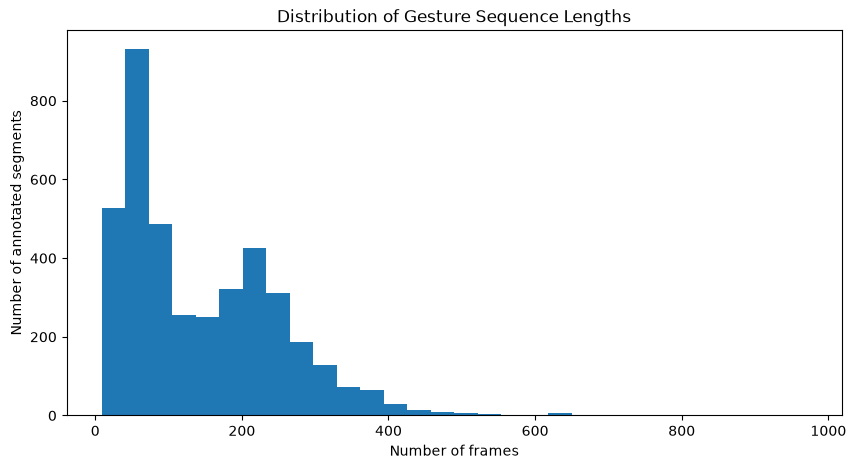

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    analysis_annotations["frame_count"],
    bins=30,
)

plt.xlabel("Number of frames")
plt.ylabel("Number of annotated segments")
plt.title("Distribution of Gesture Sequence Lengths")

plt.show()

In [7]:
analysis_annotations["frame_count"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

0.50    114.00
0.75    218.00
0.90    283.00
0.95    334.00
0.99    432.62
1.00    970.00
Name: frame_count, dtype: float64

In [8]:
SAMPLE_PER_CLASS = 5
RANDOM_STATE = 42

analysis_sample = (
    analysis_annotations
    .groupby("class_id", group_keys=False)
    .sample(
        n=SAMPLE_PER_CLASS,
        random_state=RANDOM_STATE,
    )
    .reset_index(drop=True)
)

print("Sample size:", len(analysis_sample))
print(
    "Classes represented:",
    analysis_sample["class_id"].nunique()
)

Sample size: 70
Classes represented: 14


In [9]:
print(
    analysis_sample[
        ["video", "label", "class_id", "frame_count"]
    ].head(10)
)

print("\nSamples per class:")
print(
    analysis_sample["class_id"]
    .value_counts()
    .sort_index()
)

             video label  class_id  frame_count
0    1CV12_1_R__68   D0X         1           24
1    1CV12_2_R__72   D0X         1          273
2    4CM11_11_R__1   D0X         1           80
3  1CV12_16_R__107   D0X         1          232
4    4CM11_11_R__1   D0X         1          111
5    1CV12_8_R__85   B0A         2          114
6  1CM42_32_R__170   B0A         2          268
7   1CM42_4_R__188   B0A         2          272
8    1CV12_2_R__70   B0A         2          215
9  1CV12_22_R__113   B0A         2          263

Samples per class:
class_id
1     5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
10    5
11    5
12    5
13    5
14    5
Name: count, dtype: int64


In [10]:
from tqdm.auto import tqdm

analysis_sequences = []

for _, annotation in tqdm(
    analysis_sample.iterrows(),
    total=len(analysis_sample),
    desc="Extracting landmarks",
):
    segment_detector = landmarks.create_hand_detector()

    try:
        sequence = landmarks.process_annotation(
            annotation=annotation,
            video_root=analysis_paths.videos,
            detector=segment_detector,
        )

        analysis_sequences.append(sequence)

    finally:
        segment_detector.close()

print(
    "Successfully processed:",
    len(analysis_sequences)
)

Extracting landmarks:   0%|          | 0/70 [00:00<?, ?it/s]

Successfully processed: 70


In [11]:
print('hi')

hi


In [12]:
analysis_results = pd.DataFrame(
    [
        {
            "video": sequence.video,
            "label": sequence.label,
            "class_id": sequence.class_id,
            "sequence_length": sequence.landmarks.shape[0],
            "detected_frames": sequence.hand_detected.sum(),
            "detection_rate": sequence.hand_detected.mean(),
        }
        for sequence in analysis_sequences
    ]
)

analysis_results.head()

,video,label,class_id,sequence_length,detected_frames,detection_rate
0,1CV12_1_R__68,D0X,1,24,3,0.125000
1,1CV12_2_R__72,D0X,1,273,254,0.930403
2,4CM11_11_R__1,D0X,1,80,4,0.050000
3,1CV12_16_R__107,D0X,1,232,232,1.000000
4,4CM11_11_R__1,D0X,1,111,2,0.018018


In [13]:
print(
    "Sequences processed:",
    len(analysis_results)
)

print(
    "Sequences with at least one missed detection:",
    (analysis_results["detection_rate"] < 1.0).sum()
)

Sequences processed: 70
Sequences with at least one missed detection: 36


In [14]:
analysis_results["detection_rate"].describe()

count    70.000000
mean      0.841783
std       0.295409
min       0.000000
25%       0.917953
50%       0.991722
75%       1.000000
max       1.000000
Name: detection_rate, dtype: float64

In [15]:
analysis_results.sort_values(
    "detection_rate"
).head(10)

,video,label,class_id,sequence_length,detected_frames,detection_rate
19,1CM1_4_R__232,G01,4,38,0,0.000000
47,1CM1_4_R__230,G07,10,43,0,0.000000
4,4CM11_11_R__1,D0X,1,111,2,0.018018
2,4CM11_11_R__1,D0X,1,80,4,0.050000
0,1CV12_1_R__68,D0X,1,24,3,0.125000
21,4CM11_26_R__6,G02,5,184,37,0.201087
13,4CM11_5_L__10,B0B,3,282,73,0.258865
38,4CM11_26_R__8,G05,8,130,48,0.369231
24,4CM11_7_R__36,G02,5,85,34,0.400000
34,4CM11_26_R__5,G04,7,123,51,0.414634


In [16]:
total_detected_frames = analysis_results["detected_frames"].sum()
total_frames = analysis_results["sequence_length"].sum()

overall_detection_rate = (
    total_detected_frames / total_frames
)

print("Total frames:", total_frames)
print("Detected frames:", total_detected_frames)
print(
    "Frame-level detection rate:",
    overall_detection_rate
)

Total frames: 6964
Detected frames: 5783
Frame-level detection rate: 0.830413555427915


In [17]:
class_detection_analysis = (
    analysis_results
    .groupby(["class_id", "label"])
    .agg(
        sequences=("video", "count"),
        mean_detection_rate=("detection_rate", "mean"),
        min_detection_rate=("detection_rate", "min"),
        total_frames=("sequence_length", "sum"),
        detected_frames=("detected_frames", "sum"),
    )
    .reset_index()
)

class_detection_analysis["frame_detection_rate"] = (
    class_detection_analysis["detected_frames"]
    / class_detection_analysis["total_frames"]
)

class_detection_analysis

,class_id,label,sequences,mean_detection_rate,min_detection_rate,total_frames,detected_frames,frame_detection_rate
0,1,D0X,5,0.424684,0.018018,720,495,0.687500
1,2,B0A,5,0.988583,0.973684,1132,1121,0.990283
2,3,B0B,5,0.746033,0.258865,1099,773,0.703367
3,4,G01,5,0.785714,0.000000,175,136,0.777143
4,5,G02,5,0.705403,0.201087,407,207,0.508600
5,6,G03,5,0.985498,0.939394,439,434,0.988610
6,7,G04,5,0.762737,0.414634,439,297,0.676538
7,8,G05,5,0.858669,0.369231,393,307,0.781170
8,9,G06,5,0.877164,0.594937,374,327,0.874332
9,10,G07,5,0.800000,0.000000,335,292,0.871642


In [18]:
id="bq5p7e"
worst_sequence = next(
    sequence
    for sequence in analysis_sequences
    if sequence.video == "1CM1_4_R__232"
    and sequence.label == "G01"
)

print("Video:", worst_sequence.video)
print("Label:", worst_sequence.label)
print("Sequence length:", len(worst_sequence.hand_detected))
print(
    "Detected frames:",
    worst_sequence.hand_detected.sum()
)

Video: 1CM1_4_R__232
Label: G01
Sequence length: 38
Detected frames: 0


In [21]:
print(
    worst_sequence.hand_detected.astype(int)
)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0]


In [22]:
problem_annotation = analysis_annotations[
    (analysis_annotations["video"] == "1CM1_4_R__232")
    & (analysis_annotations["label"] == "G01")
].iloc[0]

print(problem_annotation)

video          1CM1_4_R__232
label                    G01
class_id                   4
start_frame             1923
end_frame               1960
frame_count               38
Name: 91, dtype: object


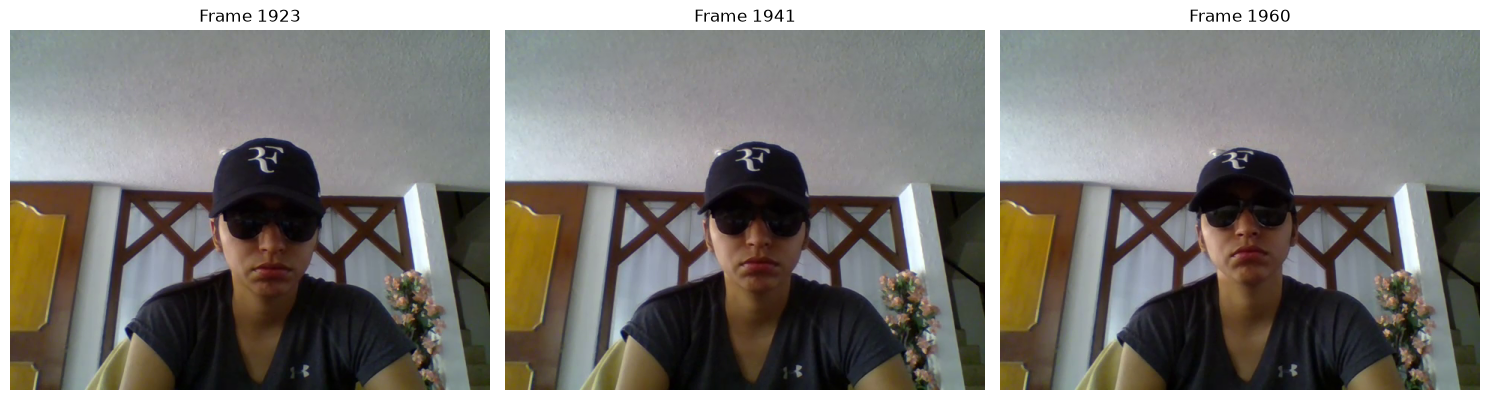

In [23]:
import cv2
import matplotlib.pyplot as plt

problem_video = (
    analysis_paths.videos
    / f"{problem_annotation['video']}.avi"
)

start_frame = int(problem_annotation["start_frame"])
end_frame = int(problem_annotation["end_frame"])

frame_positions = [
    start_frame,
    (start_frame + end_frame) // 2,
    end_frame,
]

frames_to_inspect = []

capture = cv2.VideoCapture(str(problem_video))

for frame_position in frame_positions:
    capture.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_position,
    )

    success, frame = capture.read()

    if not success or frame is None:
        raise RuntimeError(
            f"Could not read frame {frame_position}"
        )

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    frames_to_inspect.append(
        (frame_position, frame_rgb)
    )

capture.release()

fig, axes = plt.subplots(
    1,
    len(frames_to_inspect),
    figsize=(15, 5),
)

for axis, (frame_position, frame) in zip(
    axes,
    frames_to_inspect,
):
    axis.imshow(frame)
    axis.set_title(f"Frame {frame_position}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [24]:
neighbor_positions = [
    1880,
    1900,
    1920,
    1923,
    1941,
    1960,
    1980,
    2000,
]

neighbor_frames = []

capture = cv2.VideoCapture(str(problem_video))

for frame_position in neighbor_positions:
    capture.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_position,
    )

    success, frame = capture.read()

    if not success or frame is None:
        continue

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    neighbor_frames.append(
        (frame_position, frame_rgb)
    )

capture.release()

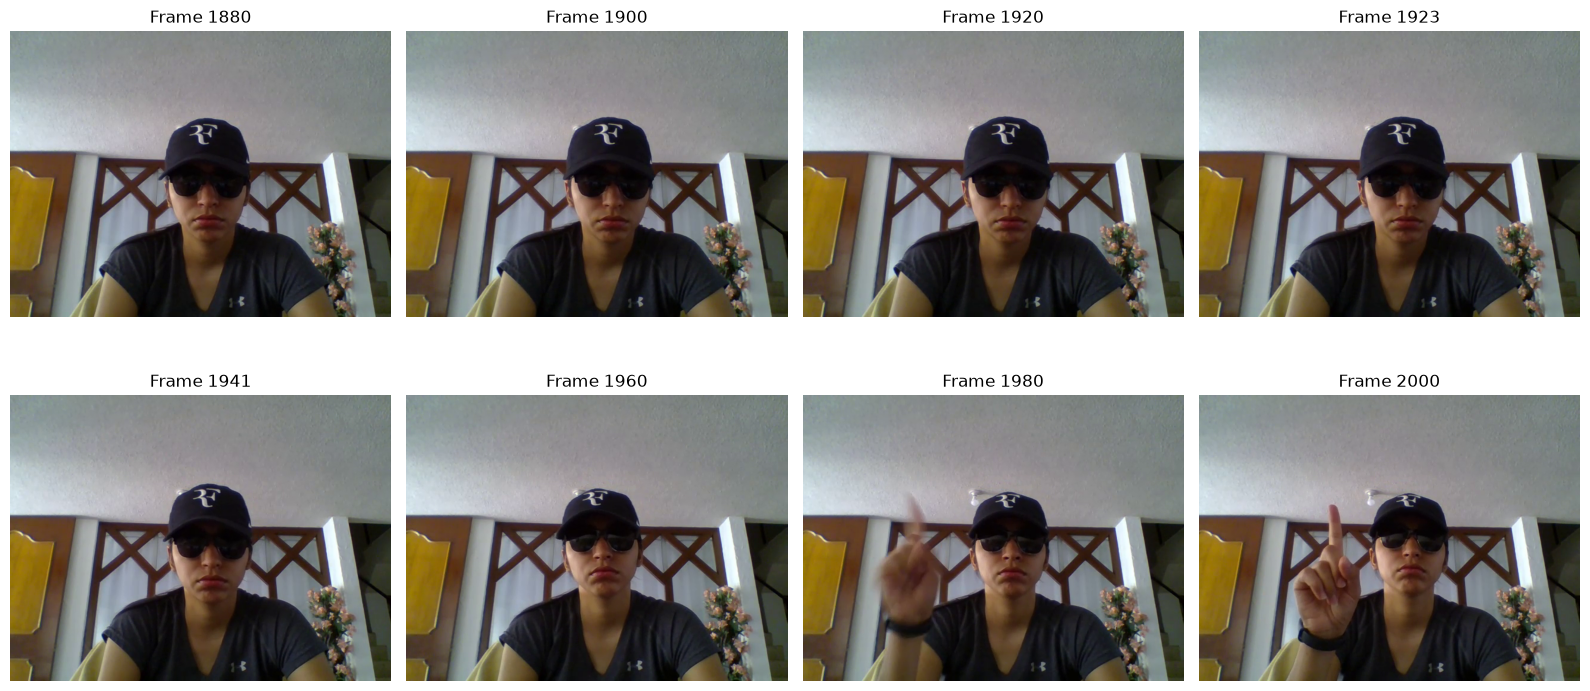

In [25]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

for axis, (frame_position, frame) in zip(
    axes.flat,
    neighbor_frames,
):
    axis.imshow(frame)
    axis.set_title(f"Frame {frame_position}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [26]:
video_annotations = analysis_annotations[
    analysis_annotations["video"] == "1CM1_4_R__232"
].sort_values("start_frame")

video_annotations[
    [
        "video",
        "label",
        "class_id",
        "start_frame",
        "end_frame",
        "frame_count",
    ]
]

,video,label,class_id,start_frame,end_frame,frame_count
78,1CM1_4_R__232,D0X,1,1,9,9
79,1CM1_4_R__232,G05,8,10,37,28
80,1CM1_4_R__232,B0A,2,38,318,281
81,1CM1_4_R__232,G11,14,319,375,57
82,1CM1_4_R__232,B0A,2,376,568,193
83,1CM1_4_R__232,G02,5,569,604,36
84,1CM1_4_R__232,B0B,3,605,813,209
85,1CM1_4_R__232,G04,7,814,845,32
86,1CM1_4_R__232,B0B,3,846,1083,238
87,1CM1_4_R__232,D0X,1,1084,1393,310


In [27]:
problem_videos = [
    "1CM1_4_R__229",
    "1CM1_4_R__230",
    "1CM1_4_R__231",
    "1CM1_4_R__232",
]

problem_annotations = (
    analysis_annotations[
        analysis_annotations["video"].isin(problem_videos)
    ]
    .sort_values(["video", "start_frame"])
)

problem_annotations[
    [
        "video",
        "label",
        "start_frame",
        "end_frame",
        "frame_count",
    ]
]

,video,label,start_frame,end_frame,frame_count
0,1CM1_4_R__229,D0X,1,17,17
1,1CM1_4_R__229,G11,18,55,38
2,1CM1_4_R__229,B0B,56,284,229
3,1CM1_4_R__229,G04,285,308,24
4,1CM1_4_R__229,B0B,309,502,194
...,...,...,...,...,...
99,1CM1_4_R__232,B0A,3330,3541,212
100,1CM1_4_R__232,G06,3542,3567,26
101,1CM1_4_R__232,B0B,3568,3766,199
102,1CM1_4_R__232,G09,3767,3809,43


In [28]:
suspicious_annotation = analysis_annotations[
    (analysis_annotations["video"] == "4CM11_26_R__6")
    & (analysis_annotations["label"] == "G02")
].iloc[0]

print(suspicious_annotation)

video          4CM11_26_R__6
label                    G02
class_id                   5
start_frame             2993
end_frame               3176
frame_count              184
Name: 3560, dtype: object


In [29]:
suspicious_video = (
    analysis_paths.videos
    / f"{suspicious_annotation['video']}.avi"
)

suspicious_start = int(
    suspicious_annotation["start_frame"]
)

suspicious_end = int(
    suspicious_annotation["end_frame"]
)

suspicious_positions = [
    suspicious_start,
    suspicious_start + (
        suspicious_end - suspicious_start
    ) // 4,
    suspicious_start + (
        suspicious_end - suspicious_start
    ) // 2,
    suspicious_start + 3 * (
        suspicious_end - suspicious_start
    ) // 4,
    suspicious_end,
]

suspicious_frames = []

capture = cv2.VideoCapture(
    str(suspicious_video)
)

for frame_position in suspicious_positions:
    capture.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_position,
    )

    success, frame = capture.read()

    if not success or frame is None:
        continue

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB,
    )

    suspicious_frames.append(
        (frame_position, frame_rgb)
    )

capture.release()

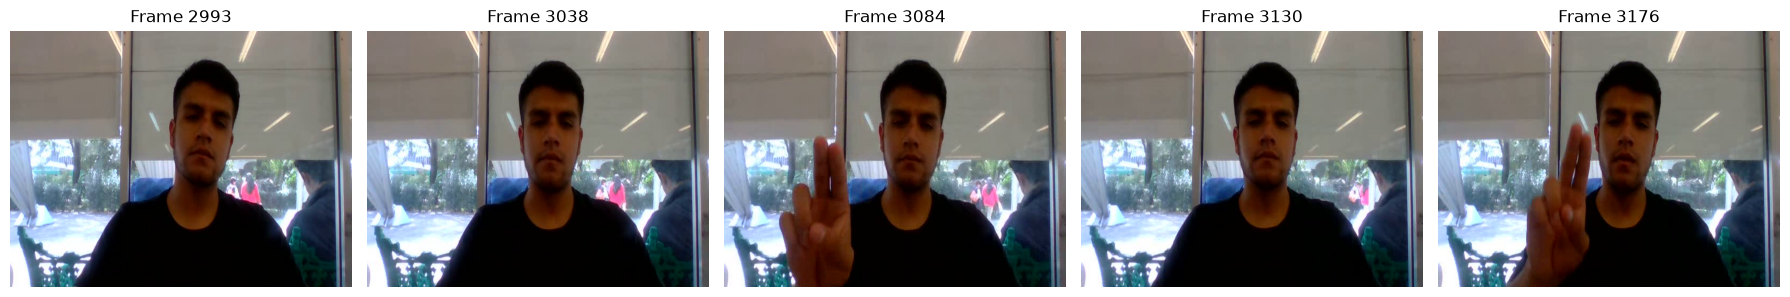

In [30]:
fig, axes = plt.subplots(
    1,
    len(suspicious_frames),
    figsize=(18, 4),
)

for axis, (frame_position, frame) in zip(
    axes,
    suspicious_frames,
):
    axis.imshow(frame)
    axis.set_title(f"Frame {frame_position}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [31]:
gesture_results = analysis_results[
    analysis_results["label"] != "D0X"
].copy()

print(
    "Gesture sequences:",
    len(gesture_results)
)

print(
    "Gesture frames:",
    gesture_results["sequence_length"].sum()
)

print(
    "Detected gesture frames:",
    gesture_results["detected_frames"].sum()
)

print(
    "Frame-level detection rate:",
    (
        gesture_results["detected_frames"].sum()
        / gesture_results["sequence_length"].sum()
    )
)

Gesture sequences: 65
Gesture frames: 6244
Detected gesture frames: 5288
Frame-level detection rate: 0.8468930172966047


In [32]:
gesture_results["detection_rate"].describe()

count    65.000000
mean      0.873868
std       0.253176
min       0.000000
25%       0.925926
50%       1.000000
75%       1.000000
max       1.000000
Name: detection_rate, dtype: float64

In [33]:
print(
    "Perfect detection:",
    (
        gesture_results["detection_rate"] == 1.0
    ).sum()
)

print(
    "At least 90% detection:",
    (
        gesture_results["detection_rate"] >= 0.90
    ).sum()
)

print(
    "Below 50% detection:",
    (
        gesture_results["detection_rate"] < 0.50
    ).sum()
)

Perfect detection: 33
At least 90% detection: 52
Below 50% detection: 8


In [34]:
low_detection_sequences = (
    gesture_results[
        gesture_results["detection_rate"] < 0.50
    ]
    .sort_values("detection_rate")
)

low_detection_sequences[
    [
        "video",
        "label",
        "class_id",
        "sequence_length",
        "detected_frames",
        "detection_rate",
    ]
]

,video,label,class_id,sequence_length,detected_frames,detection_rate
19,1CM1_4_R__232,G01,4,38,0,0.000000
47,1CM1_4_R__230,G07,10,43,0,0.000000
21,4CM11_26_R__6,G02,5,184,37,0.201087
13,4CM11_5_L__10,B0B,3,282,73,0.258865
38,4CM11_26_R__8,G05,8,130,48,0.369231
24,4CM11_7_R__36,G02,5,85,34,0.400000
34,4CM11_26_R__5,G04,7,123,51,0.414634
33,4CM11_26_R__8,G04,7,117,50,0.427350


In [35]:
## measure missing frame runs (consecutive)

In [36]:
def longest_missing_run(detection_mask):
    """Return the longest consecutive run of undetected frames."""

    longest_run = 0
    current_run = 0

    for detected in detection_mask:
        if detected:
            current_run = 0
        else:
            current_run += 1
            longest_run = max(longest_run, current_run)

    return longest_run

In [37]:
sequence_lookup = {
    (
        sequence.video,
        sequence.label,
    ): sequence
    for sequence in analysis_sequences
}

In [38]:
low_detection_analysis = low_detection_sequences.copy()

low_detection_analysis["longest_missing_run"] = [
    longest_missing_run(
        sequence_lookup[
            (row["video"], row["label"])
        ].hand_detected
    )
    for _, row in low_detection_analysis.iterrows()
]

low_detection_analysis[
    [
        "video",
        "label",
        "sequence_length",
        "detected_frames",
        "detection_rate",
        "longest_missing_run",
    ]
]

,video,label,sequence_length,detected_frames,detection_rate,longest_missing_run
19,1CM1_4_R__232,G01,38,0,0.000000,38
47,1CM1_4_R__230,G07,43,0,0.000000,43
21,4CM11_26_R__6,G02,184,37,0.201087,74
13,4CM11_5_L__10,B0B,282,73,0.258865,109
38,4CM11_26_R__8,G05,130,48,0.369231,81
24,4CM11_7_R__36,G02,85,34,0.400000,51
34,4CM11_26_R__5,G04,123,51,0.414634,39
33,4CM11_26_R__8,G04,117,50,0.427350,65


In [40]:
low_detection_analysis["missing_frames"] = (
    low_detection_analysis["sequence_length"]
    - low_detection_analysis["detected_frames"]
)

low_detection_analysis[
    [
        "video",
        "label",
        "sequence_length",
        "detected_frames",
        "missing_frames",
        "detection_rate",
        "longest_missing_run",
    ]
]

,video,label,sequence_length,detected_frames,missing_frames,detection_rate,longest_missing_run
19,1CM1_4_R__232,G01,38,0,38,0.000000,38
47,1CM1_4_R__230,G07,43,0,43,0.000000,43
21,4CM11_26_R__6,G02,184,37,147,0.201087,74
13,4CM11_5_L__10,B0B,282,73,209,0.258865,109
38,4CM11_26_R__8,G05,130,48,82,0.369231,81
24,4CM11_7_R__36,G02,85,34,51,0.400000,51
34,4CM11_26_R__5,G04,123,51,72,0.414634,39
33,4CM11_26_R__8,G04,117,50,67,0.427350,65


In [41]:
## Calculate missing-run statistics for every gesture sequence

gesture_missing_run_analysis = gesture_results.copy()

gesture_missing_run_analysis["longest_missing_run"] = [
    longest_missing_run(
        sequence_lookup[
            (row["video"], row["label"])
        ].hand_detected
    )
    for _, row in gesture_missing_run_analysis.iterrows()
]

gesture_missing_run_analysis[
    "longest_missing_run"
].describe()

count     65.000000
mean       9.553846
std       22.131024
min        0.000000
25%        0.000000
50%        0.000000
75%        3.000000
max      109.000000
Name: longest_missing_run, dtype: float64

In [42]:
gesture_missing_run_analysis[
    "longest_missing_run"
].quantile(
    [0.50, 0.75, 0.90, 0.95, 1.00]
)

0.50      0.0
0.75      3.0
0.90     38.6
0.95     62.2
1.00    109.0
Name: longest_missing_run, dtype: float64

In [43]:
gesture_missing_run_analysis["longest_missing_seconds"] = (
    gesture_missing_run_analysis["longest_missing_run"]
    / 30.0
)

gesture_missing_run_analysis[
    "longest_missing_seconds"
].describe()

count    65.000000
mean      0.318462
std       0.737701
min       0.000000
25%       0.000000
50%       0.000000
75%       0.100000
max       3.633333
Name: longest_missing_seconds, dtype: float64

In [44]:
## Sequence length vs detection rate

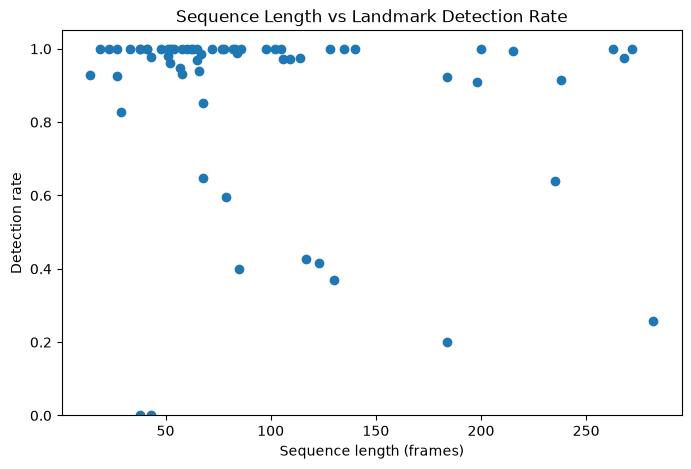

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(
    gesture_results["sequence_length"],
    gesture_results["detection_rate"],
)

plt.xlabel("Sequence length (frames)")
plt.ylabel("Detection rate")
plt.title(
    "Sequence Length vs Landmark Detection Rate"
)

plt.ylim(0, 1.05)
plt.show()

In [46]:
def detection_quality(rate):
    if rate == 1.0:
        return "100%"
    if rate >= 0.90:
        return "90-99%"
    if rate >= 0.50:
        return "50-89%"
    return "<50%"

In [47]:
quality_counts = (
    gesture_results["detection_rate"]
    .apply(detection_quality)
    .value_counts()
)

quality_counts

detection_rate
100%      33
90-99%    19
<50%       8
50-89%     5
Name: count, dtype: int64

In [48]:
class_length_analysis = (
    analysis_annotations
    .groupby("label")["frame_count"]
    .describe()
    .round(2)
)

class_length_analysis

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
B0A,745.0,217.57,67.24,9.0,177.00,214.0,257.00,624.0
B0B,743.0,222.10,70.15,15.0,178.00,216.0,258.00,623.0
D0X,922.0,166.88,138.65,9.0,51.00,121.0,257.00,970.0
G01,148.0,55.99,30.41,13.0,36.00,47.0,73.25,167.0
G02,148.0,61.04,47.79,18.0,38.00,48.5,74.00,525.0
G03,148.0,61.60,25.36,15.0,42.00,55.5,76.50,139.0
G04,149.0,65.64,28.97,13.0,43.00,60.0,79.00,181.0
G05,148.0,66.74,27.75,22.0,48.00,59.0,82.00,165.0
G06,148.0,64.85,29.47,26.0,44.00,57.0,77.50,174.0


In [49]:
candidate_lengths = [64, 96, 128, 160, 192, 256, 320, 384, 512]

coverage = {
    length: (
        analysis_annotations["frame_count"] <= length
    ).mean()
    for length in candidate_lengths
}

pd.Series(coverage).mul(100).round(2)

64     31.72
96     45.53
128    53.08
160    59.17
192    65.88
256    84.67
320    94.13
384    97.62
512    99.53
dtype: float64

In [50]:
gesture_annotations = analysis_annotations[
    analysis_annotations["label"] != "D0X"
].copy()

gesture_coverage = {
    length: (
        gesture_annotations["frame_count"] <= length
    ).mean()
    for length in candidate_lengths
}

pd.Series(
    gesture_coverage
).mul(100).round(2)

64     31.50
96     45.94
128    53.55
160    60.31
192    67.56
256    87.65
320    96.63
384    98.91
512    99.90
dtype: float64

In [51]:
class_candidate_coverage = pd.DataFrame(
    {
        length: (
            gesture_annotations
            .groupby("label")["frame_count"]
            .apply(
                lambda lengths: (
                    lengths <= length
                ).mean()
            )
        )
        for length in candidate_lengths
    }
)

class_candidate_coverage.mul(100).round(2)

,64,96,128,160,192,256,320,384,512
label,,,,,,,,,
B0A,0.81,2.95,8.72,18.93,32.35,74.63,93.96,98.26,99.87
B0B,0.81,3.50,5.92,16.96,32.17,73.76,92.06,97.31,99.87
G01,72.97,90.54,95.27,99.32,100.00,100.00,100.00,100.00,100.00
G02,67.57,89.86,96.62,98.65,99.32,99.32,99.32,99.32,99.32
G03,62.84,87.84,99.32,100.00,100.00,100.00,100.00,100.00,100.00
G04,57.05,84.56,97.99,98.66,100.00,100.00,100.00,100.00,100.00
G05,56.08,85.81,97.30,99.32,100.00,100.00,100.00,100.00,100.00
G06,63.51,83.78,95.95,97.97,100.00,100.00,100.00,100.00,100.00
G07,48.65,74.32,90.54,99.32,100.00,100.00,100.00,100.00,100.00


In [52]:
def temporal_target_length(
    sequence_length,
    short_limit=192,
    long_limit=256,
):
    if sequence_length < short_limit:
        return sequence_length

    if sequence_length <= long_limit:
        return short_limit

    return long_limit

In [53]:
length_analysis = analysis_annotations[
    analysis_annotations["label"] != "D0X"
].copy()

length_analysis["target_length"] = (
    length_analysis["frame_count"]
    .apply(temporal_target_length)
)

length_analysis["compression_ratio"] = (
    length_analysis["target_length"]
    / length_analysis["frame_count"]
)

length_analysis[
    [
        "label",
        "frame_count",
        "target_length",
        "compression_ratio",
    ]
].head(20)

,label,frame_count,target_length,compression_ratio
1,G11,38,38,1.000000
2,B0B,229,192,0.838428
3,G04,24,24,1.000000
4,B0B,194,192,0.989691
5,G05,42,42,1.000000
6,B0B,313,256,0.817891
7,G03,42,42,1.000000
8,B0A,223,192,0.860987
10,G02,25,25,1.000000
11,B0A,250,192,0.768000


In [54]:
length_analysis[
    [
        "frame_count",
        "target_length",
        "compression_ratio",
    ]
].describe()

,frame_count,target_length,compression_ratio
count,3117.000000,3117.000000,3117.000000
mean,139.379211,127.286814,0.956674
std,93.264366,74.799221,0.080984
min,9.000000,9.000000,0.410256
25%,57.000000,57.000000,0.941176
50%,113.000000,113.000000,1.000000
75%,212.000000,192.000000,1.000000
max,624.000000,256.000000,1.000000


In [55]:
print(
    "Kept unchanged:",
    (
        length_analysis["frame_count"] < 192
    ).sum()
)

print(
    "Compressed to 192:",
    (
        (
            length_analysis["frame_count"] >= 192
        )
        &
        (
            length_analysis["frame_count"] <= 256
        )
    ).sum()
)

print(
    "Compressed to 256:",
    (
        length_analysis["frame_count"] > 256
    ).sum()
)

Kept unchanged: 2096
Compressed to 192: 636
Compressed to 256: 385


In [56]:
hybrid_by_class = (
    length_analysis
    .assign(
        compression_percent=lambda df:
            (1 - df["compression_ratio"]) * 100
    )
    .groupby("label")
    .agg(
        sequences=("frame_count", "count"),
        mean_original_length=("frame_count", "mean"),
        mean_target_length=("target_length", "mean"),
        mean_compression=("compression_percent", "mean"),
        max_compression=("compression_percent", "max"),
    )
    .round(2)
)

hybrid_by_class

,sequences,mean_original_length,mean_target_length,mean_compression,max_compression
label,,,,,
B0A,745,217.57,193.79,8.70,58.97
B0B,743,222.10,195.65,9.35,58.91
G01,148,55.99,55.99,0.00,0.00
G02,148,61.04,59.22,0.35,51.24
G03,148,61.60,61.60,0.00,0.00
G04,149,65.64,65.64,0.00,0.00
G05,148,66.74,66.74,0.00,0.00
G06,148,64.85,64.85,0.00,0.00
G07,148,77.36,77.36,0.00,0.00


In [57]:
strategy_comparison = pd.DataFrame(
    {
        "fixed_192": (
            192 / length_analysis["frame_count"]
        ).clip(upper=1.0),

        "fixed_256": (
            256 / length_analysis["frame_count"]
        ).clip(upper=1.0),

        "hybrid": length_analysis["compression_ratio"],
    }
)

strategy_comparison.describe().round(3)

,fixed_192,fixed_256,hybrid
count,3117.000,3117.000,3117.000
mean,0.930,0.982,0.957
std,0.127,0.063,0.081
min,0.308,0.410,0.410
25%,0.906,1.000,0.941
50%,1.000,1.000,1.000
75%,1.000,1.000,1.000
max,1.000,1.000,1.000


In [58]:
FEATURE_DIM = 63
HIDDEN_SIZE = 128
BATCH_SIZE = 32

SEQUENCE_LENGTHS = (192, 256)

WARMUP_RUNS = 5
BENCHMARK_RUNS = 20

In [59]:
import time

import torch
import torch.nn as nn


FEATURE_DIM = 63
HIDDEN_SIZE = 128
BATCH_SIZE = 32

SEQUENCE_LENGTHS = (192, 256)

WARMUP_RUNS = 5
BENCHMARK_RUNS = 20


def benchmark_gru(sequence_length):
    """Measure GRU forward-pass time for one sequence length."""

    model = nn.GRU(
        input_size=FEATURE_DIM,
        hidden_size=HIDDEN_SIZE,
        batch_first=True,
    )

    inputs = torch.randn(
        BATCH_SIZE,
        sequence_length,
        FEATURE_DIM,
    )

    model.eval()

    with torch.inference_mode():

        for _ in range(WARMUP_RUNS):
            model(inputs)

        start_time = time.perf_counter()

        for _ in range(BENCHMARK_RUNS):
            model(inputs)

        elapsed_time = time.perf_counter() - start_time

    average_time = elapsed_time / BENCHMARK_RUNS

    return {
        "sequence_length": sequence_length,
        "parameters": sum(
            parameter.numel()
            for parameter in model.parameters()
        ),
        "average_time_ms": average_time * 1000,
    }


benchmark_results = pd.DataFrame(
    [
        benchmark_gru(sequence_length)
        for sequence_length in SEQUENCE_LENGTHS
    ]
)

benchmark_results

,sequence_length,parameters,average_time_ms
0,192,74112,39.07811
1,256,74112,48.31821


In [60]:
import numpy as np


# ---------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------

SHORT_SEQUENCE_LIMIT = 192
LONG_SEQUENCE_LIMIT = 256

SEQUENCE_STRATEGIES = {
    "fixed_192": 192,
    "fixed_256": 256,
}


# ---------------------------------------------------------
# Temporal resampling
# ---------------------------------------------------------

def resample_sequence(sequence, target_length):
    """
    Resample a temporal landmark sequence to a fixed length.

    Parameters
    ----------
    sequence : np.ndarray
        Shape: (time, features)

    target_length : int
        Desired number of timesteps.

    Returns
    -------
    np.ndarray
        Resampled sequence with shape:
        (target_length, features)
    """

    original_length = sequence.shape[0]

    if original_length == target_length:
        return sequence.copy()

    if original_length == 1:
        return np.repeat(
            sequence,
            target_length,
            axis=0,
        )

    original_positions = np.linspace(
        0,
        original_length - 1,
        num=original_length,
    )

    target_positions = np.linspace(
        0,
        original_length - 1,
        num=target_length,
    )

    resampled = np.empty(
        (target_length, sequence.shape[1]),
        dtype=np.float32,
    )

    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            original_positions,
            sequence[:, feature_index],
        )

    return resampled

In [61]:
def get_hybrid_target_length(
    sequence_length,
    short_limit=SHORT_SEQUENCE_LIMIT,
    long_limit=LONG_SEQUENCE_LIMIT,
):
    """
    Determine the target length for the hybrid strategy.
    """

    if sequence_length < short_limit:
        return sequence_length

    if sequence_length <= long_limit:
        return short_limit

    return long_limit


In [62]:
test_sequence = analysis_sequences[0].landmarks

print("Original shape:", test_sequence.shape)

resampled_192 = resample_sequence(
    test_sequence,
    target_length=192,
)

print("Resampled shape:", resampled_192.shape)

Original shape: (24, 63)
Resampled shape: (192, 63)


In [63]:
def prepare_sequence(
    sequence,
    strategy,
):
    """
    Apply one temporal strategy to a landmark sequence.
    """

    sequence_length = sequence.shape[0]

    if strategy == "fixed_192":
        return resample_sequence(
            sequence,
            target_length=SHORT_SEQUENCE_LIMIT,
        )

    if strategy == "fixed_256":
        return resample_sequence(
            sequence,
            target_length=LONG_SEQUENCE_LIMIT,
        )

    if strategy == "hybrid":
        target_length = get_hybrid_target_length(
            sequence_length
        )

        return resample_sequence(
            sequence,
            target_length=target_length,
        )

    raise ValueError(
        f"Unknown sequence strategy: {strategy}"
    )


In [64]:
test_sequence = analysis_sequences[0].landmarks

for strategy in [
    "fixed_192",
    "fixed_256",
    "hybrid",
]:
    prepared = prepare_sequence(
        test_sequence,
        strategy,
    )

    print(
        strategy,
        "→",
        prepared.shape,
    )

fixed_192 → (192, 63)
fixed_256 → (256, 63)
hybrid → (24, 63)


In [66]:
from sklearn.model_selection import train_test_split

VALIDATION_SIZE = 0.20
RANDOM_STATE = 42

NON_GESTURE_LABEL = "D0X"

In [67]:
experiment_annotations = analysis_annotations.copy()

print("Total training annotations:", len(experiment_annotations))
print(
    "Unique videos:",
    experiment_annotations["video"].nunique(),
)

Total training annotations: 4039
Unique videos: 148


In [68]:
video_names = (
    experiment_annotations["video"]
    .drop_duplicates()
    .to_numpy()
)

print("Number of videos:", len(video_names))
print("First 10 videos:")
print(video_names[:10])

Number of videos: 148
First 10 videos:
['1CM1_4_R__229' '1CM1_4_R__230' '1CM1_4_R__231' '1CM1_4_R__232'
 '1CM42_11_R__205' '1CM42_11_R__206' '1CM42_11_R__207' '1CM42_11_R__208'
 '1CM42_12_R__157' '1CM42_12_R__158']


In [69]:
train_videos, validation_videos = train_test_split(
    video_names,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

print("Training videos:", len(train_videos))
print("Validation videos:", len(validation_videos))

Training videos: 118
Validation videos: 30


In [70]:
train_video_set = set(train_videos)
validation_video_set = set(validation_videos)

train_annotations = experiment_annotations[
    experiment_annotations["video"].isin(train_video_set)
].copy()

validation_annotations = experiment_annotations[
    experiment_annotations["video"].isin(validation_video_set)
].copy()

train_annotations = train_annotations.reset_index(drop=True)
validation_annotations = validation_annotations.reset_index(drop=True)

In [71]:
print("Training annotations:", len(train_annotations))
print("Validation annotations:", len(validation_annotations))

print(
    "Training videos:",
    train_annotations["video"].nunique(),
)

print(
    "Validation videos:",
    validation_annotations["video"].nunique(),
)

Training annotations: 3210
Validation annotations: 829
Training videos: 118
Validation videos: 30


In [72]:
overlap = (
    set(train_annotations["video"])
    & set(validation_annotations["video"])
)

print("Overlapping videos:", len(overlap))
print(overlap)

Overlapping videos: 0
set()


In [73]:
train_class_counts = (
    train_annotations["label"]
    .value_counts()
    .sort_index()
)

validation_class_counts = (
    validation_annotations["label"]
    .value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame(
    {
        "train": train_class_counts,
        "validation": validation_class_counts,
    }
).fillna(0).astype(int)

class_distribution

,train,validation
label,,
B0A,593,152
B0B,592,151
D0X,726,196
G01,118,30
G02,118,30
G03,118,30
G04,119,30
G05,118,30
G06,118,30


In [74]:
class_distribution["train_percent"] = (
    class_distribution["train"]
    / class_distribution["train"].sum()
    * 100
)

class_distribution["validation_percent"] = (
    class_distribution["validation"]
    / class_distribution["validation"].sum()
    * 100
)

class_distribution.round(2)

,train,validation,train_percent,validation_percent
label,,,,
B0A,593,152,18.47,18.34
B0B,592,151,18.44,18.21
D0X,726,196,22.62,23.64
G01,118,30,3.68,3.62
G02,118,30,3.68,3.62
G03,118,30,3.68,3.62
G04,119,30,3.71,3.62
G05,118,30,3.68,3.62
G06,118,30,3.68,3.62


In [75]:
gesture_train_annotations = train_annotations[
    train_annotations["label"] != NON_GESTURE_LABEL
].copy()

gesture_validation_annotations = validation_annotations[
    validation_annotations["label"] != NON_GESTURE_LABEL
].copy()

print(
    "Gesture training annotations:",
    len(gesture_train_annotations),
)

print(
    "Gesture validation annotations:",
    len(gesture_validation_annotations),
)

Gesture training annotations: 2484
Gesture validation annotations: 633


In [76]:
print(
    "Training classes:",
    gesture_train_annotations["label"].nunique(),
)

print(
    "Validation classes:",
    gesture_validation_annotations["label"].nunique(),
)

Training classes: 13
Validation classes: 13


In [77]:
assert len(overlap) == 0

assert (
    gesture_train_annotations["video"].nunique()
    == len(train_videos)
    - len(
        set(train_videos)
        - set(gesture_train_annotations["video"])
    )
)

assert (
    gesture_validation_annotations["video"].nunique()
    <= len(validation_videos)
)

print("Video-level split checks passed.")

Video-level split checks passed.


In [78]:
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------

VALIDATION_SIZE = 0.20
RANDOM_STATE = 42
NON_GESTURE_LABEL = "D0X"


# ---------------------------------------------------------
# Prepare annotation table
# ---------------------------------------------------------

experiment_annotations = analysis_annotations.copy()

video_names = (
    experiment_annotations["video"]
    .drop_duplicates()
    .to_numpy()
)


# ---------------------------------------------------------
# Video-level train/validation split
# ---------------------------------------------------------

train_videos, validation_videos = train_test_split(
    video_names,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
)

train_video_set = set(train_videos)
validation_video_set = set(validation_videos)


train_annotations = (
    experiment_annotations[
        experiment_annotations["video"].isin(train_video_set)
    ]
    .reset_index(drop=True)
)

validation_annotations = (
    experiment_annotations[
        experiment_annotations["video"].isin(validation_video_set)
    ]
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Remove non-gesture class for the temporal experiment
# ---------------------------------------------------------

gesture_train_annotations = train_annotations[
    train_annotations["label"] != NON_GESTURE_LABEL
].copy()

gesture_validation_annotations = validation_annotations[
    validation_annotations["label"] != NON_GESTURE_LABEL
].copy()


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

overlap = (
    set(train_annotations["video"])
    & set(validation_annotations["video"])
)

train_classes = set(
    gesture_train_annotations["label"]
)

validation_classes = set(
    gesture_validation_annotations["label"]
)


assert len(overlap) == 0, (
    f"Video leakage detected: {overlap}"
)

assert train_classes == validation_classes, (
    "Train and validation do not contain the same gesture classes."
)

assert len(train_classes) == 13, (
    f"Expected 13 gesture classes, found {len(train_classes)}."
)


print("✓ Video-level split passed")
print(
    f"✓ Train: {len(train_videos)} videos, "
    f"{len(gesture_train_annotations)} gesture segments"
)
print(
    f"✓ Validation: {len(validation_videos)} videos, "
    f"{len(gesture_validation_annotations)} gesture segments"
)
print("✓ No video overlap")
print("✓ All 13 gesture classes present in both splits")

✓ Video-level split passed
✓ Train: 118 videos, 2484 gesture segments
✓ Validation: 30 videos, 633 gesture segments
✓ No video overlap
✓ All 13 gesture classes present in both splits


In [79]:
train_annotations = train_annotations.sort_values(
    ["video", "start_frame"]
).reset_index(drop=True)

validation_annotations = validation_annotations.sort_values(
    ["video", "start_frame"]
).reset_index(drop=True)

In [80]:
from tqdm.auto import tqdm


def extract_annotation_sequences(
    annotations,
    video_root,
):
    """
    Extract landmark sequences for a collection of annotations.

    A fresh MediaPipe detector is created for each video.
    """

    sequences = []

    grouped_annotations = annotations.groupby(
        "video",
        sort=False,
    )

    for video_name, video_annotations in tqdm(
        grouped_annotations,
        total=annotations["video"].nunique(),
        desc="Extracting videos",
    ):

        video_path = (
            video_root
            / f"{video_name}.avi"
        )

        detector = landmarks.create_hand_detector()

        try:

            for _, annotation in video_annotations.iterrows():

                sequence = landmarks.process_annotation(
                    annotation=annotation,
                    video_root=video_root,
                    detector=detector,
                )

                sequences.append(sequence)

        finally:
            detector.close()

    return sequences

In [82]:
train_sequences = extract_annotation_sequences(
    annotations=gesture_train_annotations,
    video_root=analysis_paths.videos,
)

Extracting videos:   0%|          | 0/118 [00:00<?, ?it/s]

RuntimeError: Could not decode frame 3686 from video: D:\Datasets\IPN Hand\videos\videos\1CM42_11_R__205.avi

In [83]:
problem_video = "1CM42_11_R__205"

problem_annotations = gesture_train_annotations[
    gesture_train_annotations["video"] == problem_video
].copy()

problem_annotations[
    [
        "video",
        "label",
        "class_id",
        "start_frame",
        "end_frame",
        "frame_count",
    ]
]

,video,label,class_id,start_frame,end_frame,frame_count
105,1CM42_11_R__205,G01,4,35,76,42
106,1CM42_11_R__205,B0B,3,77,302,226
107,1CM42_11_R__205,G07,10,303,361,59
108,1CM42_11_R__205,B0B,3,362,586,225
109,1CM42_11_R__205,G11,14,587,629,43
110,1CM42_11_R__205,B0B,3,630,944,315
111,1CM42_11_R__205,G04,7,945,987,43
112,1CM42_11_R__205,B0A,2,988,1214,227
114,1CM42_11_R__205,G08,11,1608,1654,47
115,1CM42_11_R__205,B0A,2,1655,2000,346


In [84]:
video_path = (
    analysis_paths.videos
    / f"{problem_video}.avi"
)

capture = cv2.VideoCapture(str(video_path))

metadata_frame_count = int(
    capture.get(cv2.CAP_PROP_FRAME_COUNT)
)

fps = capture.get(cv2.CAP_PROP_FPS)

print("Video:", problem_video)
print("OpenCV frame count:", metadata_frame_count)
print("FPS:", fps)

capture.release()

Video: 1CM42_11_R__205
OpenCV frame count: 3686
FPS: 30.0


In [85]:
test_positions = [
    3680,
    3681,
    3682,
    3683,
    3684,
    3685,
    3686,
    3687,
    3688,
    3689,
    3690,
]

capture = cv2.VideoCapture(str(video_path))

results = []

for position in test_positions:
    capture.set(
        cv2.CAP_PROP_POS_FRAMES,
        position,
    )

    success, frame = capture.read()

    results.append(
        {
            "frame": position,
            "decoded": success and frame is not None,
        }
    )

capture.release()

pd.DataFrame(results)

,frame,decoded
0,3680,True
1,3681,True
2,3682,True
3,3683,True
4,3684,True
5,3685,True
6,3686,False
7,3687,False
8,3688,False
9,3689,False


In [86]:
problem_annotations[
    [
        "label",
        "start_frame",
        "end_frame",
        "frame_count",
    ]
]

,label,start_frame,end_frame,frame_count
105,G01,35,76,42
106,B0B,77,302,226
107,G07,303,361,59
108,B0B,362,586,225
109,G11,587,629,43
110,B0B,630,944,315
111,G04,945,987,43
112,B0A,988,1214,227
114,G08,1608,1654,47
115,B0A,1655,2000,346


In [87]:
print(
    "OpenCV frame count:",
    metadata_frame_count
)

print(
    "Maximum annotated frame:",
    problem_annotations["end_frame"].max()
)

OpenCV frame count: 3686
Maximum annotated frame: 3686


In [88]:
effective_end_frame = min(
    end_frame,
    actual_frame_count - 1,
)

NameError: name 'actual_frame_count' is not defined

In [89]:
def extract_annotation_sequences(
    annotations,
    video_root,
):
    """
    Extract landmark sequences for annotations.

    Frame ranges are clipped to the physically readable
    video boundary.
    """

    sequences = []

    grouped_annotations = annotations.groupby(
        "video",
        sort=False,
    )

    for video_name, video_annotations in tqdm(
        grouped_annotations,
        total=annotations["video"].nunique(),
        desc="Extracting videos",
    ):

        video_path = video_root / f"{video_name}.avi"

        capture = cv2.VideoCapture(str(video_path))

        if not capture.isOpened():
            raise RuntimeError(
                f"Could not open video: {video_path}"
            )

        actual_frame_count = int(
            capture.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        capture.release()

        detector = landmarks.create_hand_detector()

        try:
            for _, annotation in video_annotations.iterrows():

                safe_end_frame = min(
                    int(annotation["end_frame"]),
                    actual_frame_count - 1,
                )

                if safe_end_frame < int(annotation["start_frame"]):
                    raise RuntimeError(
                        f"Invalid frame range for "
                        f"{video_name}: "
                        f"{annotation['start_frame']}–"
                        f"{annotation['end_frame']}"
                    )

                adjusted_annotation = annotation.copy()

                adjusted_annotation["end_frame"] = safe_end_frame

                sequence = landmarks.process_annotation(
                    annotation=adjusted_annotation,
                    video_root=video_root,
                    detector=detector,
                )

                sequences.append(sequence)

        finally:
            detector.close()

    return sequences

In [90]:
train_sequences = extract_annotation_sequences(
    annotations=gesture_train_annotations,
    video_root=analysis_paths.videos,
)

Extracting videos:   0%|          | 0/118 [00:00<?, ?it/s]

In [91]:
validation_sequences = extract_annotation_sequences(
    annotations=gesture_validation_annotations,
    video_root=analysis_paths.videos,
)

Extracting videos:   0%|          | 0/30 [00:00<?, ?it/s]

In [92]:
assert len(train_sequences) == len(
    gesture_train_annotations
)

assert len(validation_sequences) == len(
    gesture_validation_annotations
)

assert all(
    sequence.landmarks.shape[1] == 63
    for sequence in train_sequences + validation_sequences
)

print("✓ EXTRACTION COMPLETE")
print(f"Train: {len(train_sequences)}")
print(f"Validation: {len(validation_sequences)}")

✓ EXTRACTION COMPLETE
Train: 2484
Validation: 633


In [93]:
from pathlib import Path
import pickle


LANDMARK_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "landmarks"
)

LANDMARK_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


with open(
    LANDMARK_CACHE_DIR / "train_sequences.pkl",
    "wb",
) as file:
    pickle.dump(
        train_sequences,
        file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


with open(
    LANDMARK_CACHE_DIR / "validation_sequences.pkl",
    "wb",
) as file:
    pickle.dump(
        validation_sequences,
        file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


print("✓ Landmark sequences cached")

✓ Landmark sequences cached


In [94]:
train_cache = (
    LANDMARK_CACHE_DIR / "train_sequences.pkl"
)

validation_cache = (
    LANDMARK_CACHE_DIR / "validation_sequences.pkl"
)

assert train_cache.exists()
assert validation_cache.exists()

print("✓ Cache files exist")
print(f"✓ Train sequences: {len(train_sequences)}")
print(f"✓ Validation sequences: {len(validation_sequences)}")

✓ Cache files exist
✓ Train sequences: 2484
✓ Validation sequences: 633


In [95]:
import numpy as np


SHORT_SEQUENCE_LIMIT = 192
LONG_SEQUENCE_LIMIT = 256


def resample_sequence(
    sequence,
    target_length,
):
    """
    Resample a landmark sequence along its time dimension.

    Parameters
    ----------
    sequence : np.ndarray
        Shape: (time, features)

    target_length : int
        Desired number of timesteps.

    Returns
    -------
    np.ndarray
        Shape: (target_length, features)
    """

    original_length = sequence.shape[0]

    if original_length == target_length:
        return sequence.copy()

    original_positions = np.linspace(
        0,
        original_length - 1,
        num=original_length,
    )

    target_positions = np.linspace(
        0,
        original_length - 1,
        num=target_length,
    )

    resampled = np.empty(
        (target_length, sequence.shape[1]),
        dtype=np.float32,
    )

    for feature_index in range(sequence.shape[1]):

        resampled[:, feature_index] = np.interp(
            target_positions,
            original_positions,
            sequence[:, feature_index],
        )

    return resampled

In [96]:
def prepare_sequence(
    sequence,
    strategy,
):
    """
    Apply one temporal preprocessing strategy.
    """

    sequence_length = sequence.shape[0]

    if strategy == "fixed_192":

        return resample_sequence(
            sequence,
            SHORT_SEQUENCE_LIMIT,
        )

    if strategy == "fixed_256":

        return resample_sequence(
            sequence,
            LONG_SEQUENCE_LIMIT,
        )

    if strategy == "hybrid":

        if sequence_length < SHORT_SEQUENCE_LIMIT:
            target_length = sequence_length

        elif sequence_length <= LONG_SEQUENCE_LIMIT:
            target_length = SHORT_SEQUENCE_LIMIT

        else:
            target_length = LONG_SEQUENCE_LIMIT

        return resample_sequence(
            sequence,
            target_length,
        )

    raise ValueError(
        f"Unknown strategy: {strategy}"
    )

In [97]:
def prepare_dataset(
    sequences,
    strategy,
):
    """
    Prepare landmark sequences using one temporal strategy.

    Returns
    -------
    X : list[np.ndarray]
        Temporal landmark sequences.

    y : np.ndarray
        Integer class IDs.
    """

    X = []
    y = []

    for sequence in sequences:

        processed = prepare_sequence(
            sequence.landmarks,
            strategy,
        )

        X.append(processed)
        y.append(sequence.class_id)

    return X, np.array(y)

In [98]:
strategies = [
    "fixed_192",
    "fixed_256",
    "hybrid",
]


prepared_datasets = {}

for strategy in strategies:

    train_X, train_y = prepare_dataset(
        train_sequences,
        strategy,
    )

    validation_X, validation_y = prepare_dataset(
        validation_sequences,
        strategy,
    )

    prepared_datasets[strategy] = {
        "train_X": train_X,
        "train_y": train_y,
        "validation_X": validation_X,
        "validation_y": validation_y,
    }

print("✓ Temporal representations created")

✓ Temporal representations created


In [99]:
for strategy in strategies:

    dataset = prepared_datasets[strategy]

    assert len(dataset["train_X"]) == 2484
    assert len(dataset["validation_X"]) == 633

    assert len(dataset["train_y"]) == 2484
    assert len(dataset["validation_y"]) == 633


# Fixed-length checks
assert all(
    sequence.shape == (192, 63)
    for sequence in prepared_datasets["fixed_192"]["train_X"]
)

assert all(
    sequence.shape == (256, 63)
    for sequence in prepared_datasets["fixed_256"]["train_X"]
)


# Hybrid should contain both shorter and capped sequences
hybrid_lengths = {
    sequence.shape[0]
    for sequence in prepared_datasets["hybrid"]["train_X"]
}

assert any(
    length < 192
    for length in hybrid_lengths
)

assert 192 in hybrid_lengths
assert 256 in hybrid_lengths


print("✓ Temporal preprocessing passed")
print("✓ 192 representation: valid")
print("✓ 256 representation: valid")
print("✓ Hybrid representation: valid")

✓ Temporal preprocessing passed
✓ 192 representation: valid
✓ 256 representation: valid
✓ Hybrid representation: valid


In [100]:
import torch
from torch.utils.data import Dataset, DataLoader


BATCH_SIZE = 32
RANDOM_STATE = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [158]:
class GestureDataset(Dataset):
    """
    PyTorch dataset for the 13 IPN gesture classes.

    Converts IPN gesture IDs 2–14
    into PyTorch class indices 0–12.
    """

    def __init__(
        self,
        sequences,
        labels,
    ):
        self.sequences = sequences

        # IPN gesture IDs: 2–14
        # PyTorch indices: 0–12
        self.labels = np.asarray(labels) - 2

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):

        sequence = torch.tensor(
            self.sequences[index],
            dtype=torch.float32,
        )

        label = torch.tensor(
            self.labels[index],
            dtype=torch.long,
        )

        return sequence, label

In [144]:
from torch.nn.utils.rnn import pad_sequence


def collate_sequences(batch):
    """
    Pad variable-length sequences within a batch.
    """

    sequences, labels = zip(*batch)

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    lengths = torch.tensor(
        [sequence.shape[0] for sequence in sequences],
        dtype=torch.long,
    )

    labels = torch.stack(labels)

    return (
        padded_sequences,
        lengths,
        labels,
    )

In [159]:
dataloaders = {}

for strategy in strategies:

    dataset = prepared_datasets[strategy]

    train_dataset = GestureDataset(
        dataset["train_X"],
        dataset["train_y"],
    )

    validation_dataset = GestureDataset(
        dataset["validation_X"],
        dataset["validation_y"],
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_sequences,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_sequences,
    )

    dataloaders[strategy] = {
        "train": train_loader,
        "validation": validation_loader,
    }

print("✓ DataLoaders rebuilt")

✓ DataLoaders rebuilt


In [146]:
for strategy in strategies:

    batch = next(
        iter(dataloaders[strategy]["train"])
    )

    inputs, lengths, labels = batch

    print(
        f"{strategy}: "
        f"inputs={tuple(inputs.shape)}, "
        f"lengths={tuple(lengths.shape)}, "
        f"labels={tuple(labels.shape)}"
    )

fixed_192: inputs=(32, 192, 63), lengths=(32,), labels=(32,)
fixed_256: inputs=(32, 256, 63), lengths=(32,), labels=(32,)
hybrid: inputs=(32, 256, 63), lengths=(32,), labels=(32,)


In [147]:
for strategy in strategies:

    loader = dataloaders[strategy]["train"]

    inputs, lengths, labels = next(
        iter(loader)
    )

    assert inputs.ndim == 3
    assert inputs.shape[0] <= BATCH_SIZE
    assert inputs.shape[2] == 63

    assert lengths.ndim == 1
    assert labels.ndim == 1

    assert len(lengths) == len(labels)
    assert len(lengths) == inputs.shape[0]


print("✓ GRU data pipeline passed")

✓ GRU data pipeline passed


In [148]:
INPUT_SIZE = 63
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = 13
DROPOUT = 0.0

In [149]:
import torch.nn as nn


class GestureGRU(nn.Module):
    """
    GRU-based classifier for temporal hand-landmark sequences.
    """

    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(
        self,
        x,
        lengths,
    ):
        """
        Forward pass using packed variable-length sequences.
        """

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(packed)

        final_hidden = hidden[-1]

        logits = self.classifier(
            final_hidden
        )

        return logits

In [135]:
import torch.nn as nn


class GestureGRU(nn.Module):
    """
    GRU-based classifier for temporal hand-landmark sequences.
    """

    def __init__(
        self,
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(
        self,
        x,
        lengths,
    ):
        """
        Forward pass using packed variable-length sequences.
        """

        packed = nn.utils.rnn.pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(packed)

        final_hidden = hidden[-1]

        logits = self.classifier(
            final_hidden
        )

        return logits

In [150]:
model = GestureGRU().to(DEVICE)

strategy = "fixed_192"

inputs, lengths, labels = next(
    iter(dataloaders[strategy]["train"])
)

inputs = inputs.to(DEVICE)
labels = labels.to(DEVICE)

with torch.no_grad():
    outputs = model(
        inputs,
        lengths,
    )

print("Input shape:", tuple(inputs.shape))
print("Output shape:", tuple(outputs.shape))

Input shape: (32, 192, 63)
Output shape: (32, 13)


In [151]:
assert outputs.shape == (
    inputs.shape[0],
    NUM_CLASSES,
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("✓ GRU forward pass passed")
print(f"✓ Parameters: {parameter_count:,}")
print("✓ Output classes:", NUM_CLASSES)

✓ GRU forward pass passed
✓ Parameters: 75,789
✓ Output classes: 13


In [152]:
import random
import time

import numpy as np
import torch
import torch.nn as nn


# ---------------------------------------------------------
# Controlled experiment configuration
# ---------------------------------------------------------

SEED = 42

LEARNING_RATE = 1e-3
NUM_EPOCHS = 15

EXPERIMENT_STRATEGIES = [
    "fixed_192",
    "fixed_256",
    "hybrid",
]


def set_seed(seed=SEED):
    """Make the experiment as reproducible as practical."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed()

print("✓ Training configuration ready")

✓ Training configuration ready


In [153]:
def create_training_components(model):
    """
    Create the loss function and optimizer for one model.
    """

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    return criterion, optimizer

In [154]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
):
    """
    Train the model for one epoch.
    """

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, lengths, labels in dataloader:

        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(
            inputs,
            lengths,
        )

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [155]:
def evaluate(
    model,
    dataloader,
    criterion,
):
    """
    Evaluate the model without updating its weights.
    """

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, lengths, labels in dataloader:

            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(
                inputs,
                lengths,
            )

            loss = criterion(
                logits,
                labels,
            )

            total_loss += (
                loss.item()
                * labels.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [156]:
def run_experiment(strategy):
    """
    Train and validate one GRU using one temporal strategy.
    """

    set_seed()

    model = GestureGRU().to(DEVICE)

    criterion, optimizer = (
        create_training_components(model)
    )

    train_loader = (
        dataloaders[strategy]["train"]
    )

    validation_loader = (
        dataloaders[strategy]["validation"]
    )

    history = []

    start_time = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):

        train_loss, train_accuracy = (
            train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
            )
        )

        validation_loss, validation_accuracy = (
            evaluate(
                model,
                validation_loader,
                criterion,
            )
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
            }
        )

        print(
            f"{strategy} | "
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {validation_accuracy:.4f}"
        )

    elapsed_time = (
        time.perf_counter() - start_time
    )

    return model, pd.DataFrame(history), elapsed_time

In [160]:
model_192, history_192, time_192 = (
    run_experiment("fixed_192")
)

print(
    f"\n✓ 192 experiment completed "
    f"in {time_192 / 60:.2f} minutes"
)

fixed_192 | Epoch 01/15 | Train Acc: 0.2540 | Val Acc: 0.2938
fixed_192 | Epoch 02/15 | Train Acc: 0.2834 | Val Acc: 0.2622
fixed_192 | Epoch 03/15 | Train Acc: 0.3921 | Val Acc: 0.5024


KeyboardInterrupt: 

In [1]:
import pickle

with open(
    LANDMARK_CACHE_DIR / "train_sequences.pkl",
    "rb",
) as file:
    train_sequences = pickle.load(file)

with open(
    LANDMARK_CACHE_DIR / "validation_sequences.pkl",
    "rb",
) as file:
    validation_sequences = pickle.load(file)

print("✓ Cached landmarks loaded")
print(f"Train: {len(train_sequences)}")
print(f"Validation: {len(validation_sequences)}")

NameError: name 'LANDMARK_CACHE_DIR' is not defined

In [ ]:
prepared_datasets = {}

for strategy in strategies:

    train_X, train_y = prepare_dataset(
        train_sequences,
        strategy,
    )

    validation_X, validation_y = prepare_dataset(
        validation_sequences,
        strategy,
    )

    prepared_datasets[strategy] = {
        "train_X": train_X,
        "train_y": train_y,
        "validation_X": validation_X,
        "validation_y": validation_y,
    }

print("✓ Temporal representations recreated")

In [2]:
from pathlib import Path
import pickle


LANDMARK_CACHE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "landmarks"
)

train_cache = (
    LANDMARK_CACHE_DIR / "train_sequences.pkl"
)

validation_cache = (
    LANDMARK_CACHE_DIR / "validation_sequences.pkl"
)

assert train_cache.exists(), (
    f"Missing cache: {train_cache}"
)

assert validation_cache.exists(), (
    f"Missing cache: {validation_cache}"
)


with open(train_cache, "rb") as file:
    train_sequences = pickle.load(file)

with open(validation_cache, "rb") as file:
    validation_sequences = pickle.load(file)


print("✓ Cached landmarks loaded")
print(f"Train: {len(train_sequences)}")
print(f"Validation: {len(validation_sequences)}")

NameError: name 'PROJECT_ROOT' is not defined